In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

# Les imports pour le Machine Learning Classique
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#Les imports pour le Deep Learning (Keras/Tensorflow)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, Input
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.applications.vgg16 import VGG16

#Les imports des bibliothèques utils de la prof
import utils_ClassIm as utils

print("------Bibliothèques chargées avec succès.------")

------Bibliothèques chargées avec succès.------


#### 1ère partie : Classification un modèle de machine learning sur les caractéristiques extraites.


In [92]:
#Imortation du dataset. 

Xdf = pd.read_csv("database.csv") 

#On visualise la structure du dataset
n,p = Xdf.shape
print(f"Taille du dataset : ({n}, {p})\n")
Xdf.head()


Taille du dataset : (2688, 30)



,Numero,Classe,SousClasse,GaborFeature0,GaborFeature1,GaborFeature2,GaborFeature3,GaborFeature4,GaborFeature5,GaborFeature6,...,GaborFeature17,GaborFeature18,GaborFeature19,GaborFeature20,GaborFeature21,GaborFeature22,GaborFeature23,Y_Feature,Cr_Feature,Cb_Feature
0,1927,NATUREL,OPEN_COUNTRY,-0.534358,-0.525756,-0.569507,-0.526244,-0.758949,-0.777145,-0.655355,...,-0.245392,-0.350766,-0.139132,-0.638998,-0.593121,-0.531703,-0.231393,0.468970,0.848787,-2.490682
1,2076,ARTIFICIEL,RUE,0.111617,0.225386,0.719857,0.509317,1.327478,1.404515,0.396153,...,1.359529,0.792866,0.670435,0.818410,0.837560,0.535152,0.098582,0.135082,0.527263,-0.477937
2,1012,ARTIFICIEL,VILLE,-0.175443,-0.052435,0.877849,0.067135,0.396117,0.129128,1.834266,...,0.728218,0.369247,0.001506,-0.286736,0.401835,0.802573,0.158772,-0.822426,0.127975,0.144827
3,2069,ARTIFICIEL,RUE,-0.239083,0.130569,0.201182,0.221323,0.263732,0.827890,1.515108,...,2.133495,0.701045,0.373932,0.242101,0.413113,0.288646,0.403911,0.764572,-0.459236,0.106642
4,951,ARTIFICIEL,VILLE,0.670929,0.289145,0.246102,-0.200038,0.892492,-0.377802,-0.475454,...,-0.527731,-0.631941,-0.305346,0.424133,-0.365025,-0.489855,-0.428821,1.020113,-1.272951,1.255535


On remarque que notre dataset est constitué de 2688 lignes et de 30 colonnes, la première représente le numéro de l'image les 2 suivantes sont respectivement les classes et sous-classes de chaque image et
les 27 suivantes (de la 4 à la 30e) représentent les caractéristiques



In [93]:
Xdf.dtypes


Numero              int64
Classe             object
SousClasse         object
GaborFeature0     float64
GaborFeature1     float64
GaborFeature2     float64
GaborFeature3     float64
GaborFeature4     float64
GaborFeature5     float64
GaborFeature6     float64
GaborFeature7     float64
GaborFeature8     float64
GaborFeature9     float64
GaborFeature10    float64
GaborFeature11    float64
GaborFeature12    float64
GaborFeature13    float64
GaborFeature14    float64
GaborFeature15    float64
GaborFeature16    float64
GaborFeature17    float64
GaborFeature18    float64
GaborFeature19    float64
GaborFeature20    float64
GaborFeature21    float64
GaborFeature22    float64
GaborFeature23    float64
Y_Feature         float64
Cr_Feature        float64
Cb_Feature        float64
dtype: object

In [94]:
Xdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2688 entries, 0 to 2687
Data columns (total 30 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Numero          2688 non-null   int64  
 1   Classe          2688 non-null   object 
 2   SousClasse      2688 non-null   object 
 3   GaborFeature0   2688 non-null   float64
 4   GaborFeature1   2688 non-null   float64
 5   GaborFeature2   2688 non-null   float64
 6   GaborFeature3   2688 non-null   float64
 7   GaborFeature4   2688 non-null   float64
 8   GaborFeature5   2688 non-null   float64
 9   GaborFeature6   2688 non-null   float64
 10  GaborFeature7   2688 non-null   float64
 11  GaborFeature8   2688 non-null   float64
 12  GaborFeature9   2688 non-null   float64
 13  GaborFeature10  2688 non-null   float64
 14  GaborFeature11  2688 non-null   float64
 15  GaborFeature12  2688 non-null   float64
 16  GaborFeature13  2688 non-null   float64
 17  GaborFeature14  2688 non-null   f

In [95]:
Xdf.describe()

,Numero,GaborFeature0,GaborFeature1,GaborFeature2,GaborFeature3,GaborFeature4,GaborFeature5,GaborFeature6,GaborFeature7,GaborFeature8,...,GaborFeature17,GaborFeature18,GaborFeature19,GaborFeature20,GaborFeature21,GaborFeature22,GaborFeature23,Y_Feature,Cr_Feature,Cb_Feature
count,2688.000000,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,...,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03
mean,1343.500000,1.850372e-17,7.004979e-17,1.321694e-17,1.004487e-16,-1.206046e-17,4.229421e-17,-8.987520e-17,3.965082e-17,1.453863e-17,...,2.312965e-17,-1.169699e-16,-8.723181e-17,5.286776e-17,-1.050747e-16,1.982541e-18,-6.872809e-17,2.511219e-17,1.956107e-16,-4.282289e-16
std,776.103086,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,...,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00
min,0.000000,-5.507909e-01,-5.507426e-01,-6.685841e-01,-7.358574e-01,-9.051396e-01,-9.724596e-01,-9.628479e-01,-8.754606e-01,-8.467024e-01,...,-9.067962e-01,-8.892949e-01,-8.979148e-01,-8.561555e-01,-8.308871e-01,-9.119378e-01,-8.833166e-01,-2.941101e+00,-4.540489e+00,-4.839633e+00
25%,671.750000,-4.945687e-01,-4.913480e-01,-5.779625e-01,-6.146567e-01,-6.771426e-01,-6.981778e-01,-6.636477e-01,-6.276447e-01,-5.660138e-01,...,-5.969946e-01,-5.806993e-01,-6.036092e-01,-6.387780e-01,-5.934916e-01,-6.438069e-01,-6.374225e-01,-6.349965e-01,-5.938265e-01,-5.175380e-01
50%,1343.500000,-3.604874e-01,-3.244246e-01,-3.408673e-01,-3.303246e-01,-3.185775e-01,-3.041918e-01,-2.904148e-01,-3.020918e-01,-3.060493e-01,...,-2.727703e-01,-2.763170e-01,-2.935209e-01,-3.289518e-01,-2.851326e-01,-2.968150e-01,-3.027789e-01,5.921503e-02,-1.789951e-02,4.175597e-02
75%,2015.250000,7.276819e-02,9.053203e-02,1.870731e-01,2.169256e-01,3.173186e-01,3.718199e-01,3.814867e-01,2.629260e-01,1.779027e-01,...,2.460474e-01,2.325573e-01,2.009202e-01,2.796222e-01,2.977321e-01,3.293230e-01,2.727309e-01,6.211426e-01,5.572163e-01,6.385948e-01
max,2687.000000,1.434079e+01,2.069380e+01,1.271028e+01,9.979707e+00,9.893661e+00,8.248066e+00,1.105859e+01,9.588065e+00,1.208070e+01,...,1.174286e+01,1.209896e+01,9.955945e+00,1.098245e+01,2.285846e+01,1.154647e+01,1.054416e+01,3.758650e+00,5.770646e+00,4.162559e+00


Chaque feature est du type float ( variable quantitaitve) la classe et la sous-classe sont des object (texte non encodé) tandis que le numéro est un entier entre 0 et 2687 et le dataset ne présente pas de valeur manquante

In [ ]:
# Chargement de la base
df = pd.read_csv('./database.csv')

# Récupération des features (colonnes 3 à 26 pour Gabor, et les 3 dernières pour YCbCr)
X_features = df.iloc[:, 3:].values 
y_labels = df['SousClasse'] # On travaille sur les 8 classes (Côte, Forêt, etc.)

# Encodage des labels (String -> Int)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
class_names = le.classes_

# Split Apprentissage / Test (on prend 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_encoded, test_size=0.2, random_state=42)

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape Train: {X_train_scaled.shape}, Shape Test: {X_test_scaled.shape}")
print(f"Sous-Classes: {class_names}")

Shape Train: (2150, 27), Shape Test: (538, 27)
Sous-Classes: ['AUTOROUTE' 'COTE' 'FORET' 'GRANDBATIMENT' 'MONTAGNE' 'OPEN_COUNTRY'
 'RUE' 'VILLE']


##### Analyse descriptive

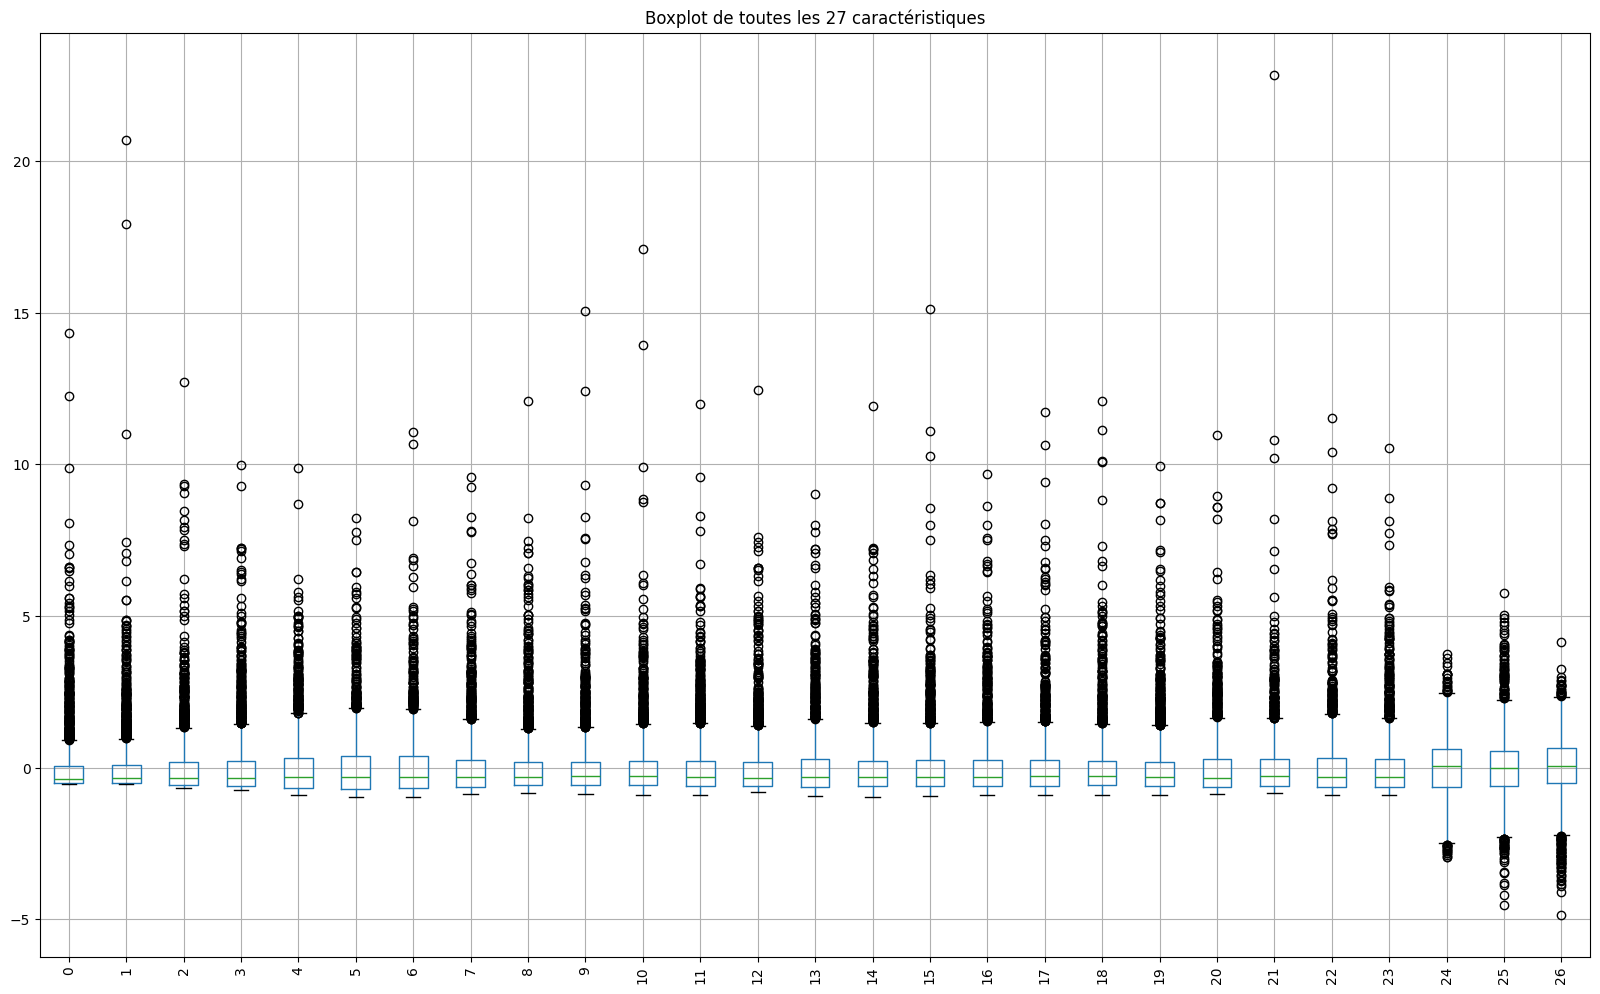

In [101]:

#Tracer des boxplot 
plt.figure(figsize=(20, 12)) # Ajuste la taille pour 27 features
pd.DataFrame(X_features).boxplot()

plt.title('Boxplot de toutes les 27 caractéristiques')
plt.xticks(rotation=90) # Fait pivoter les noms des features
plt.show()

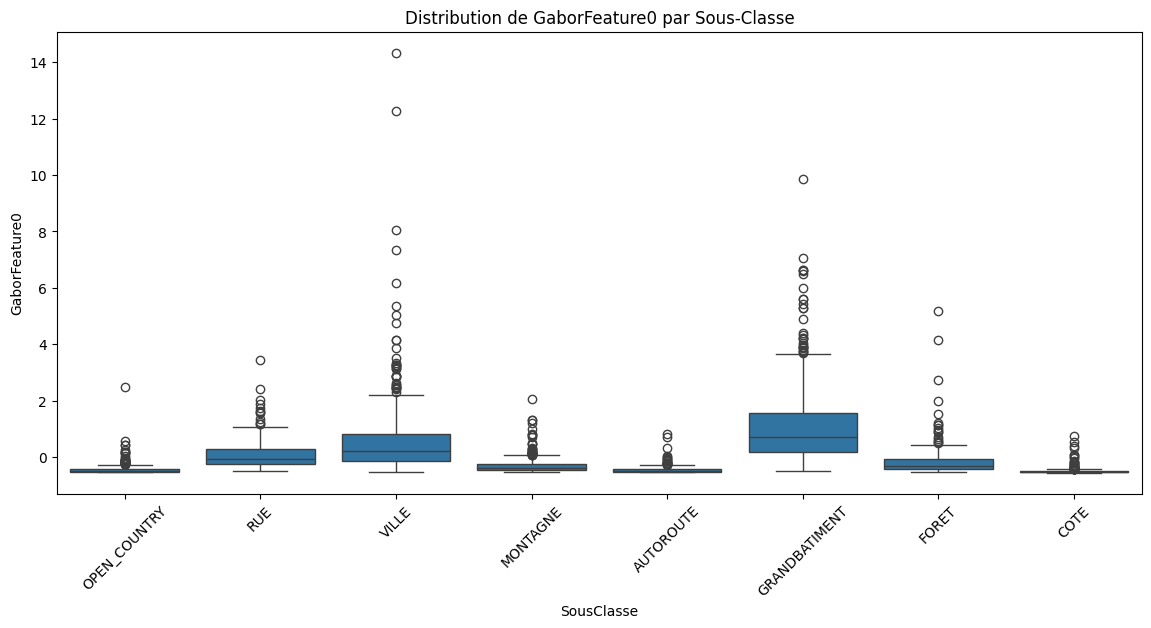

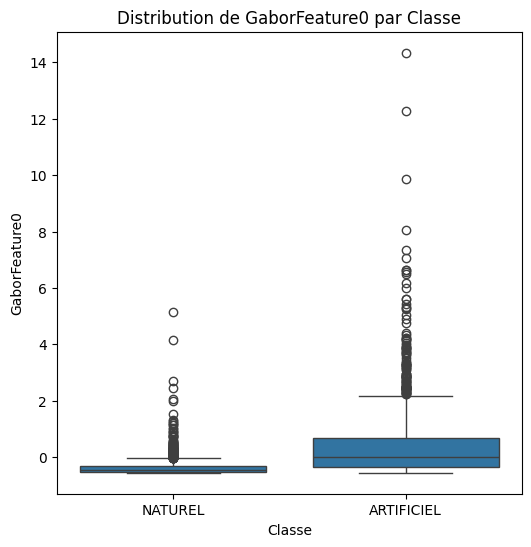

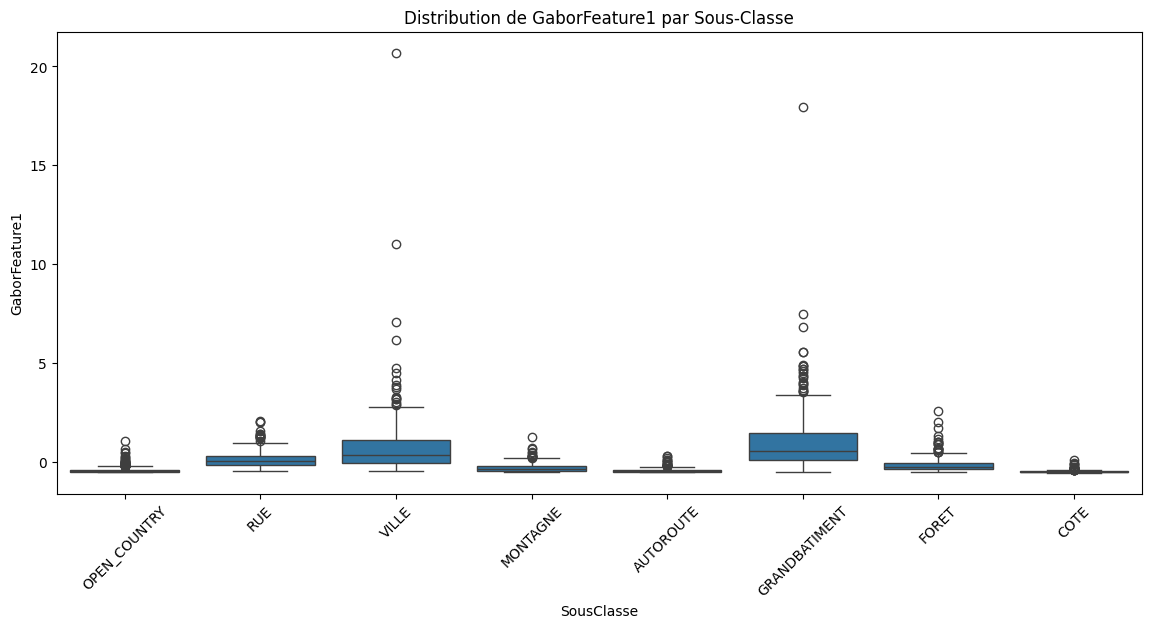

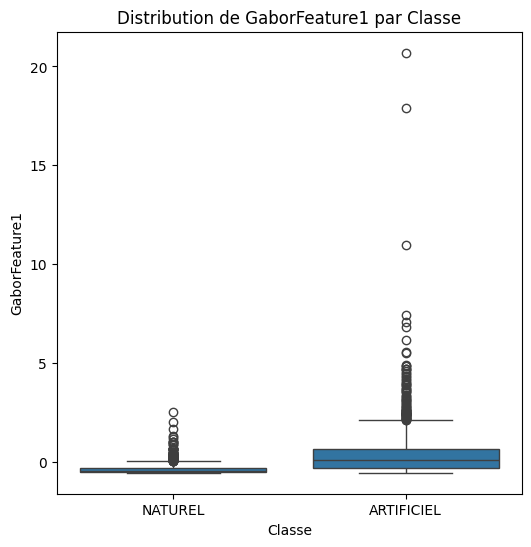

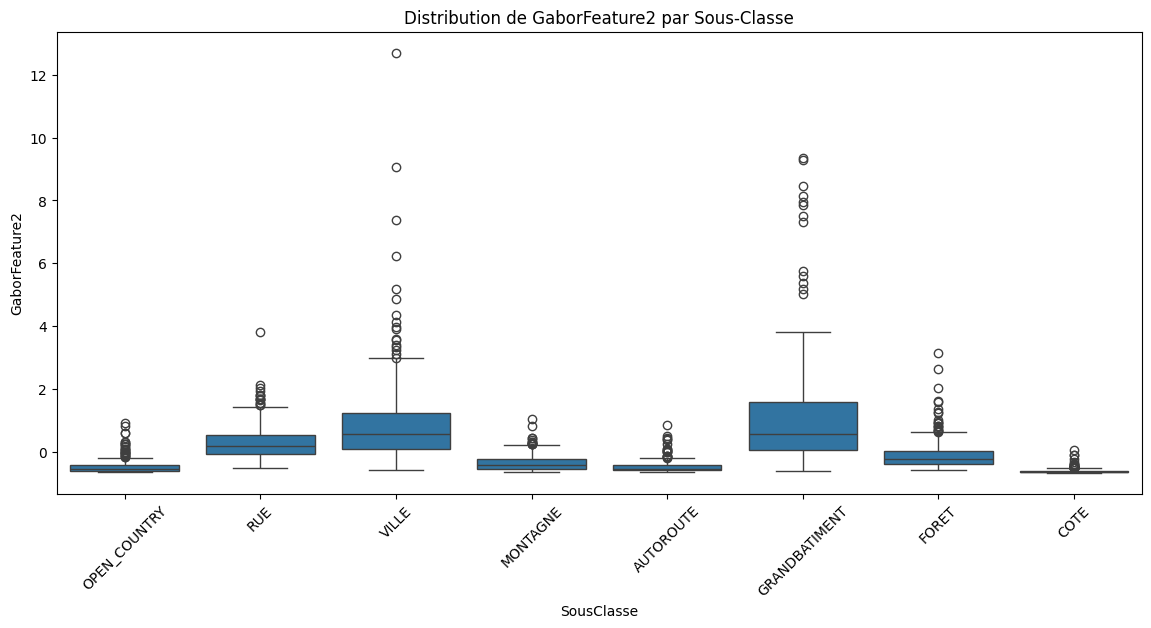

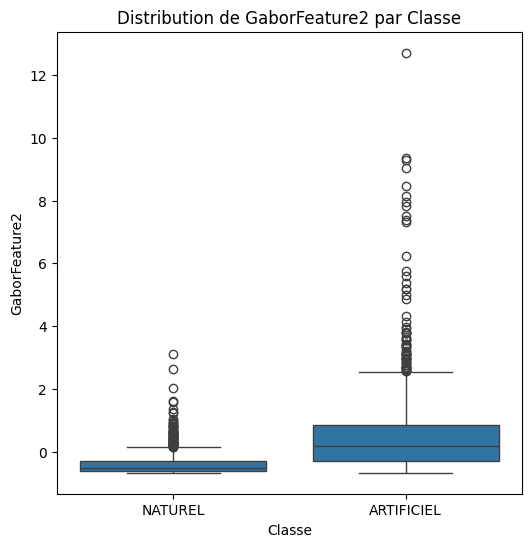

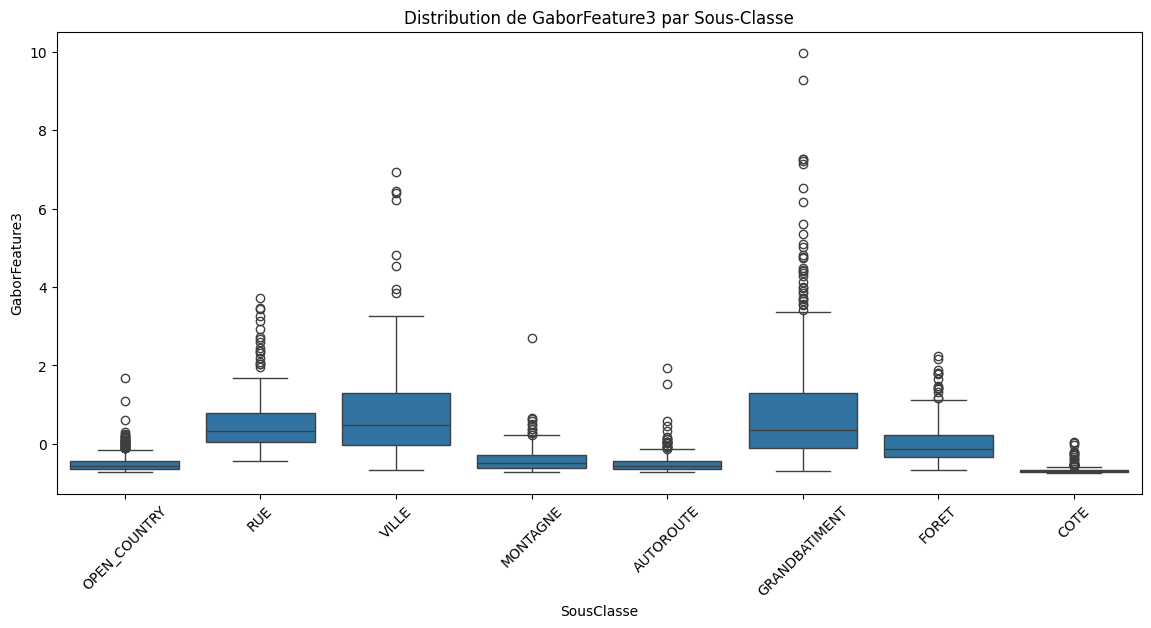

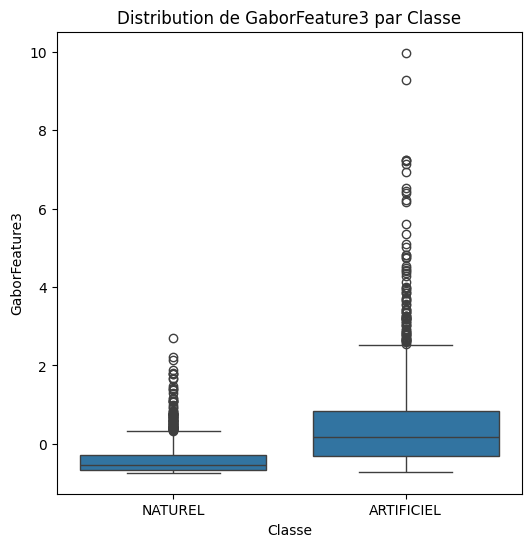

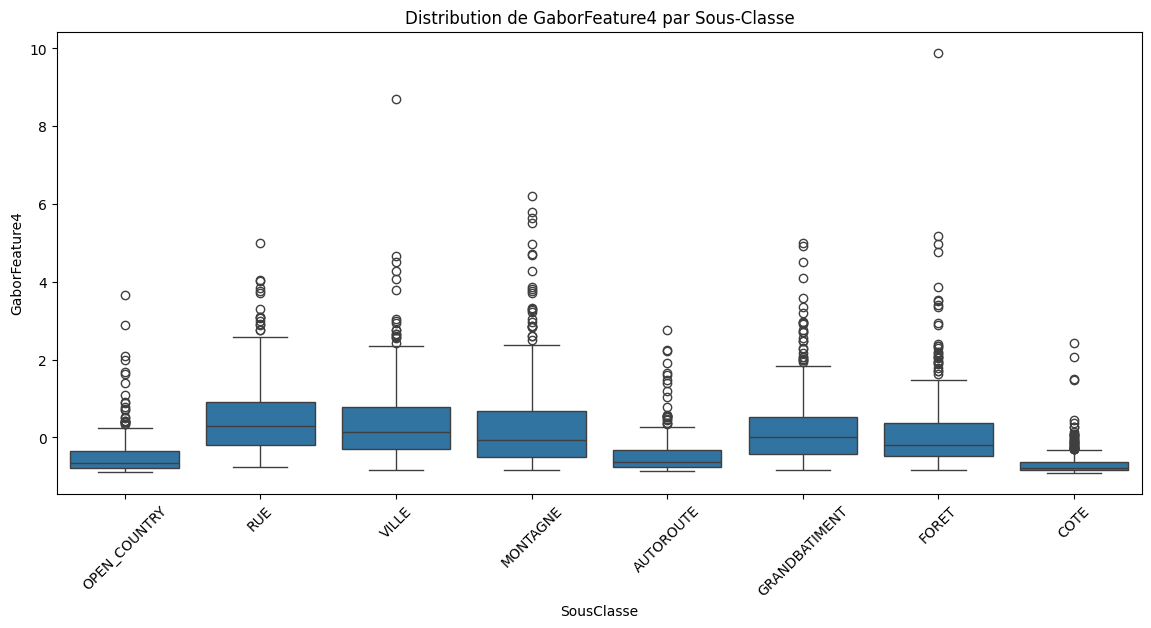

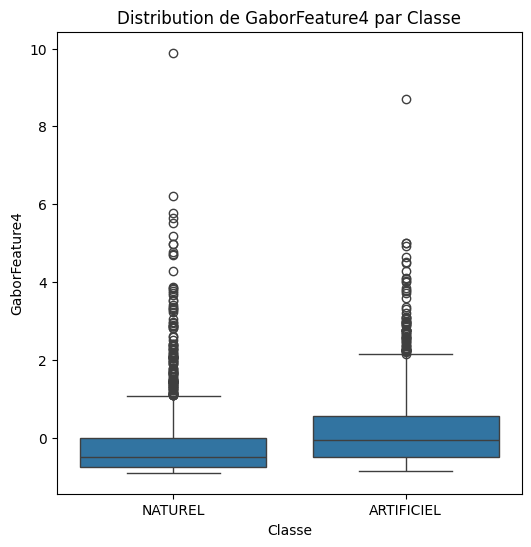

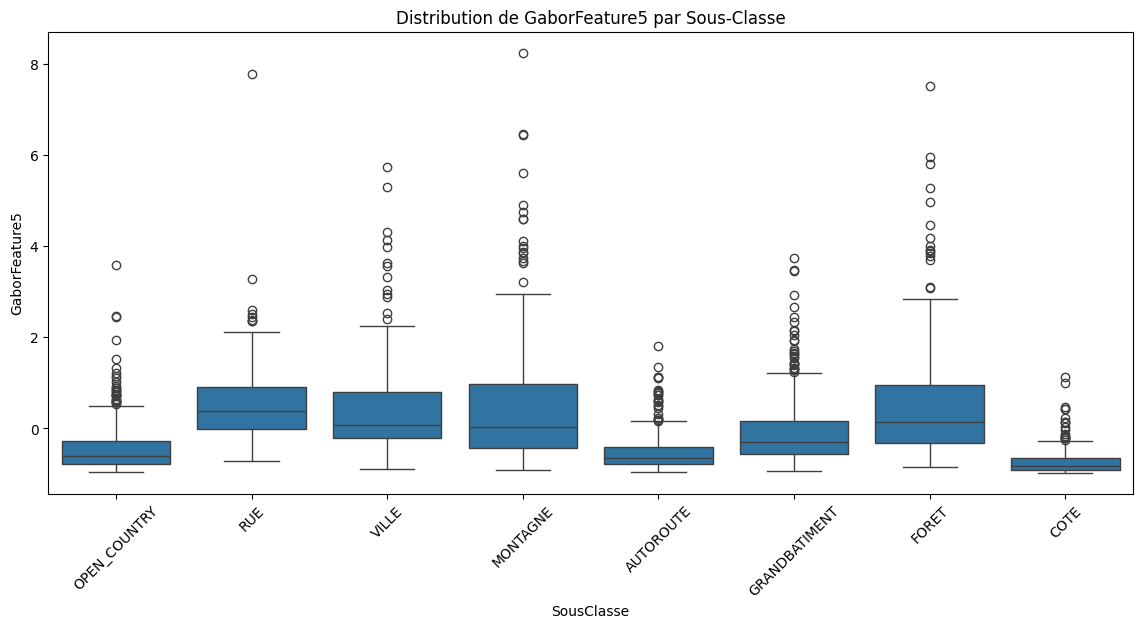

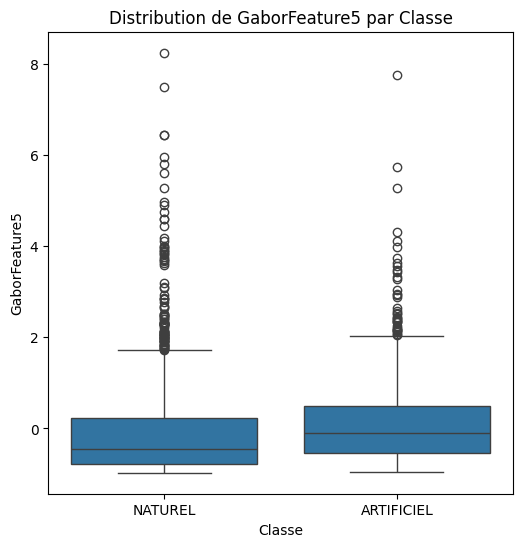

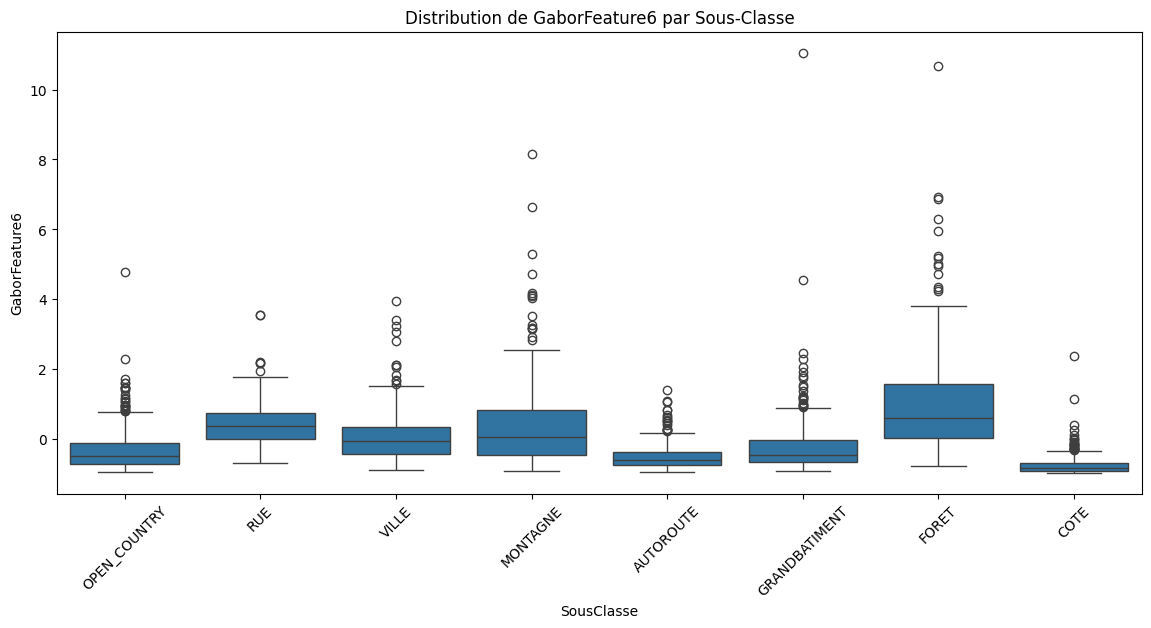

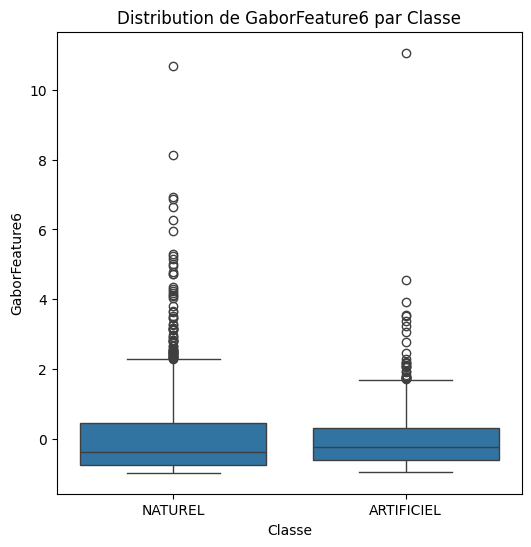

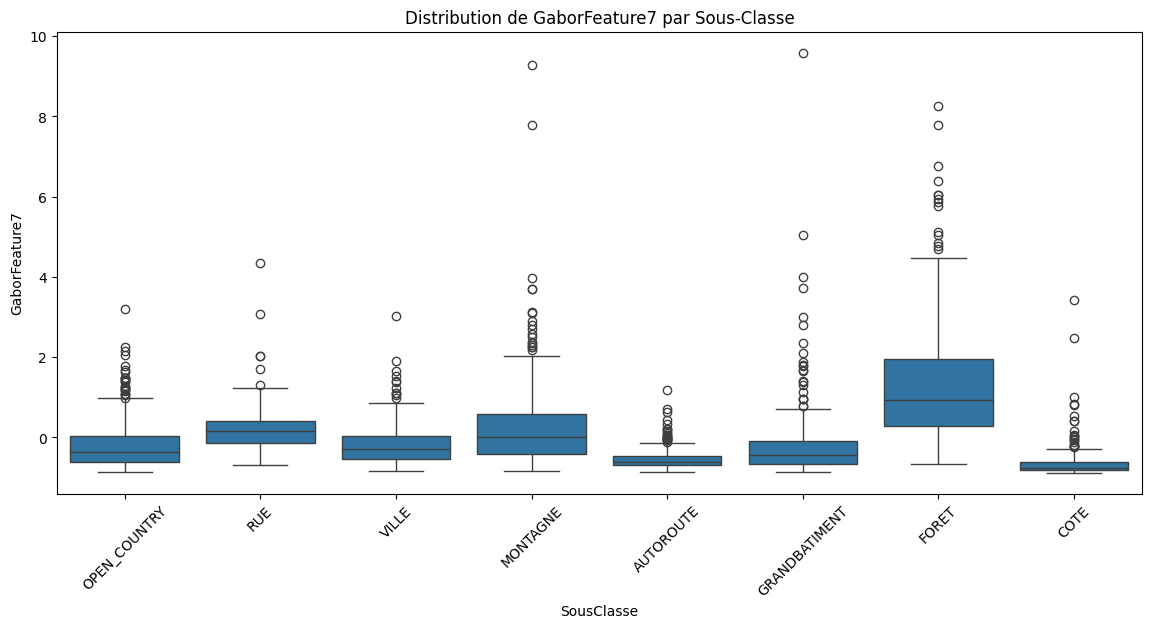

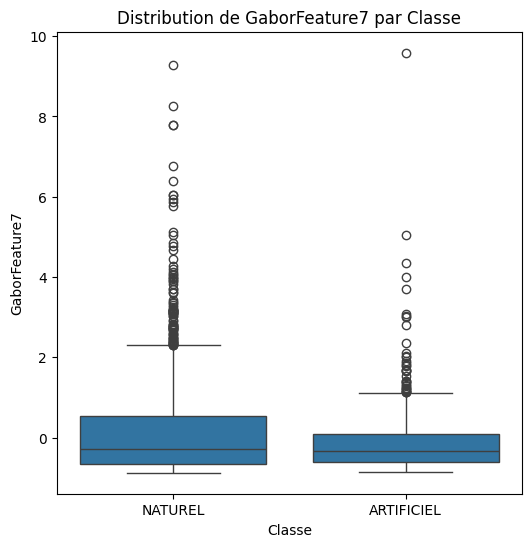

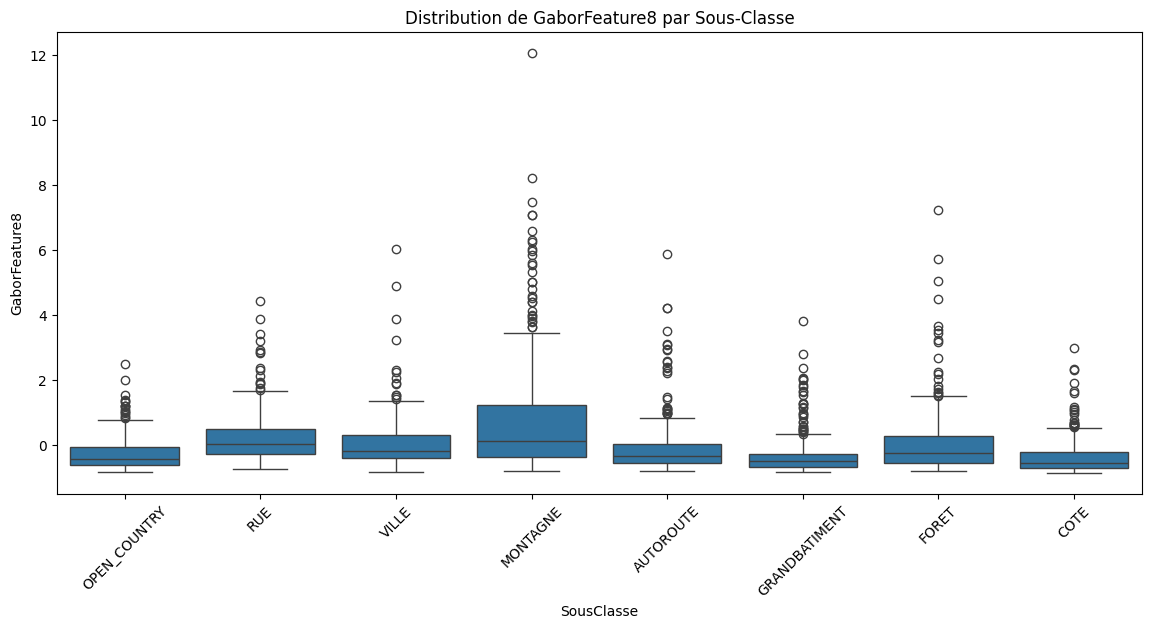

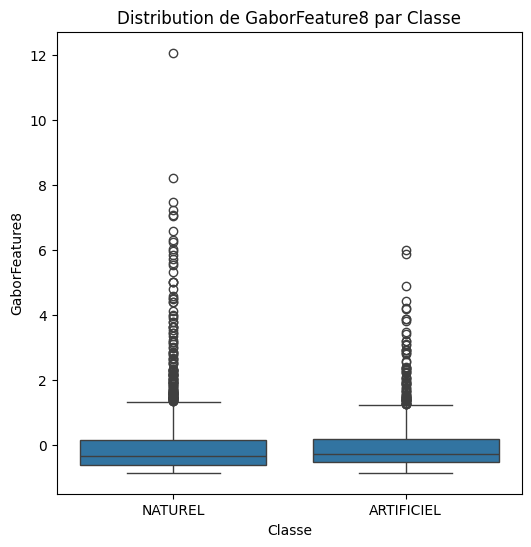

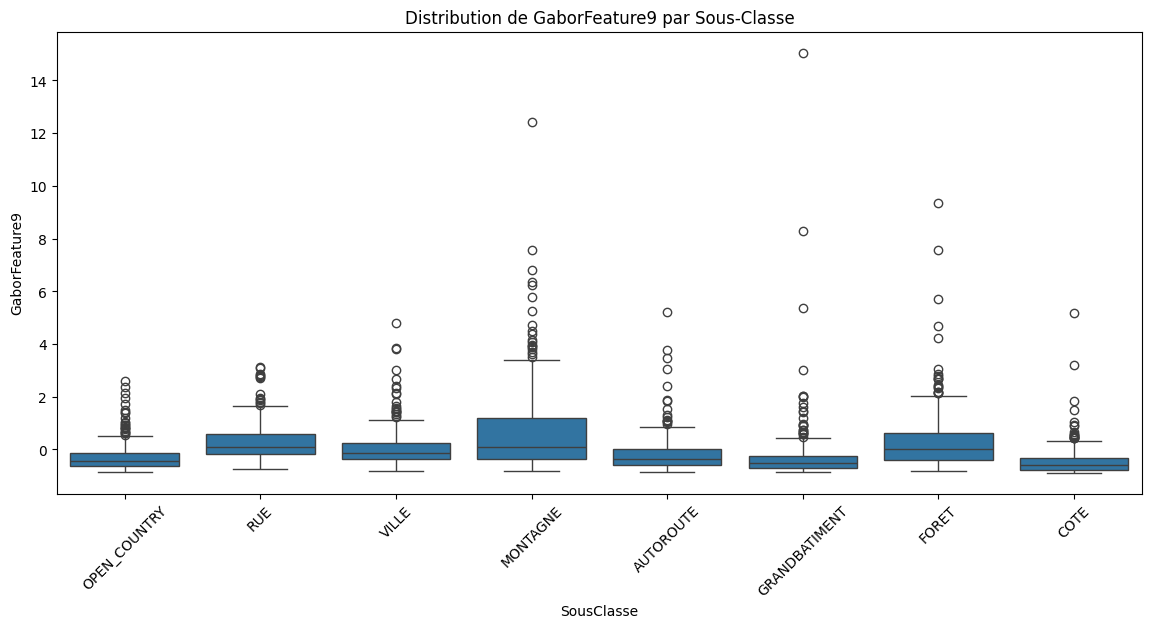

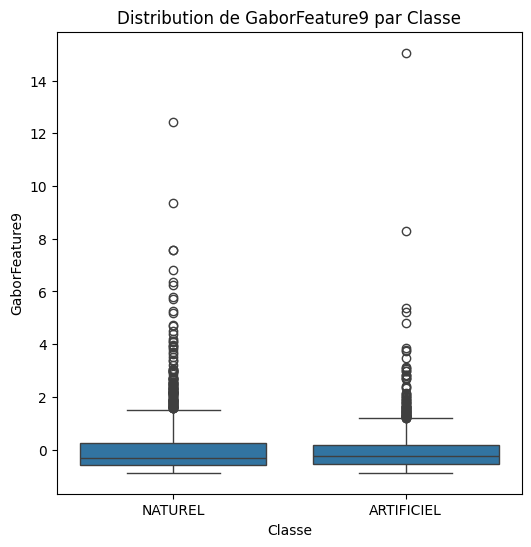

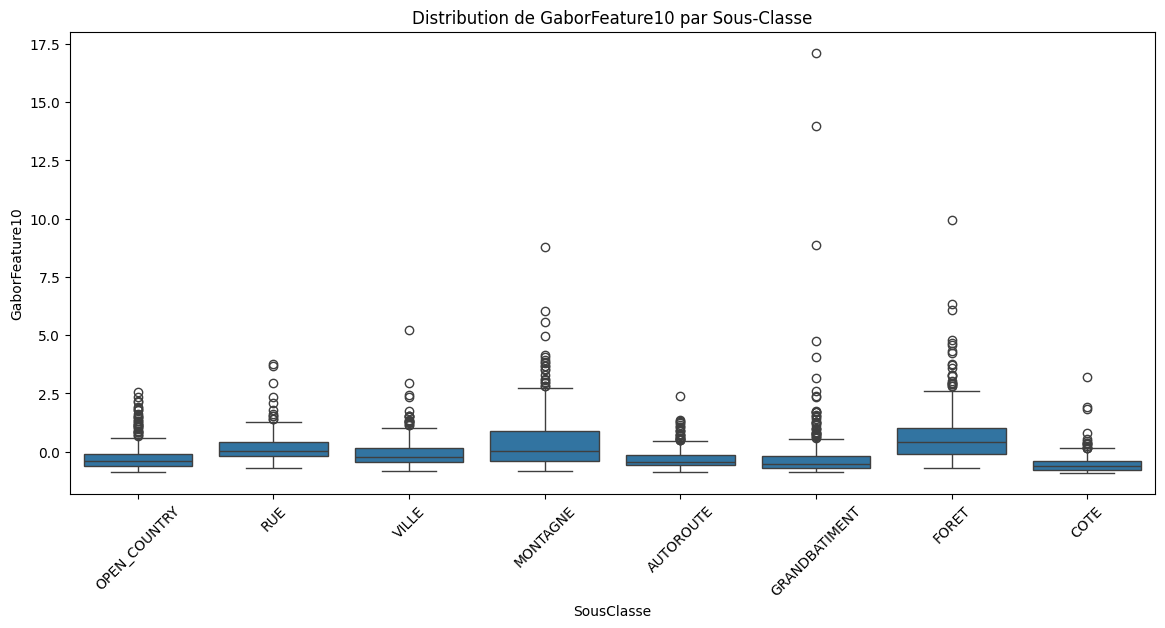

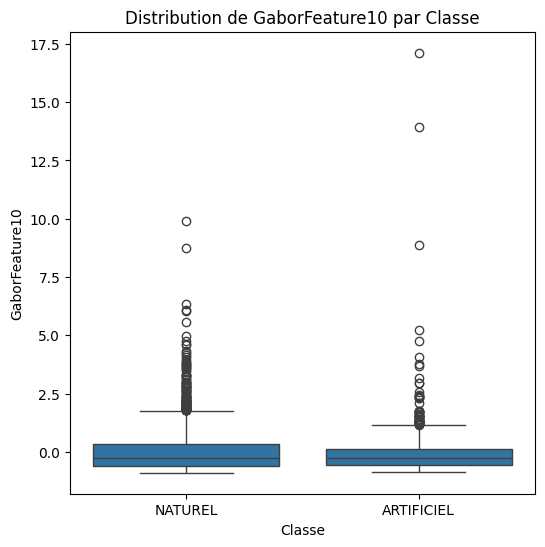

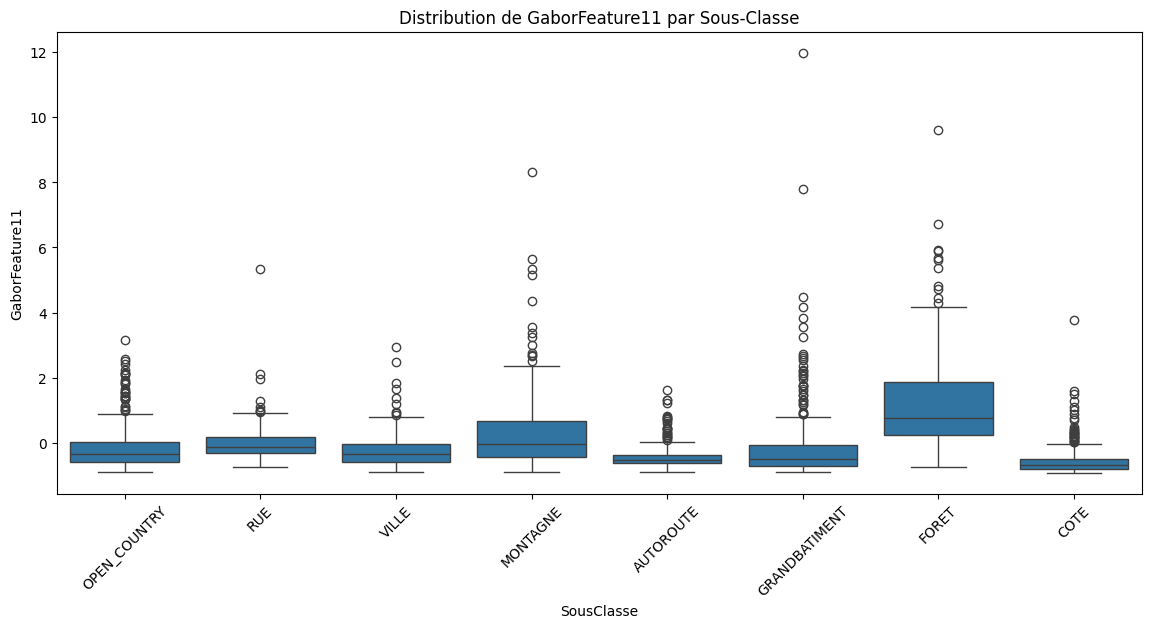

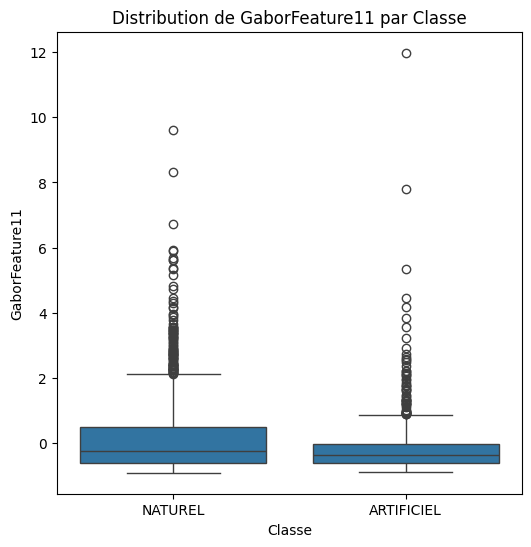

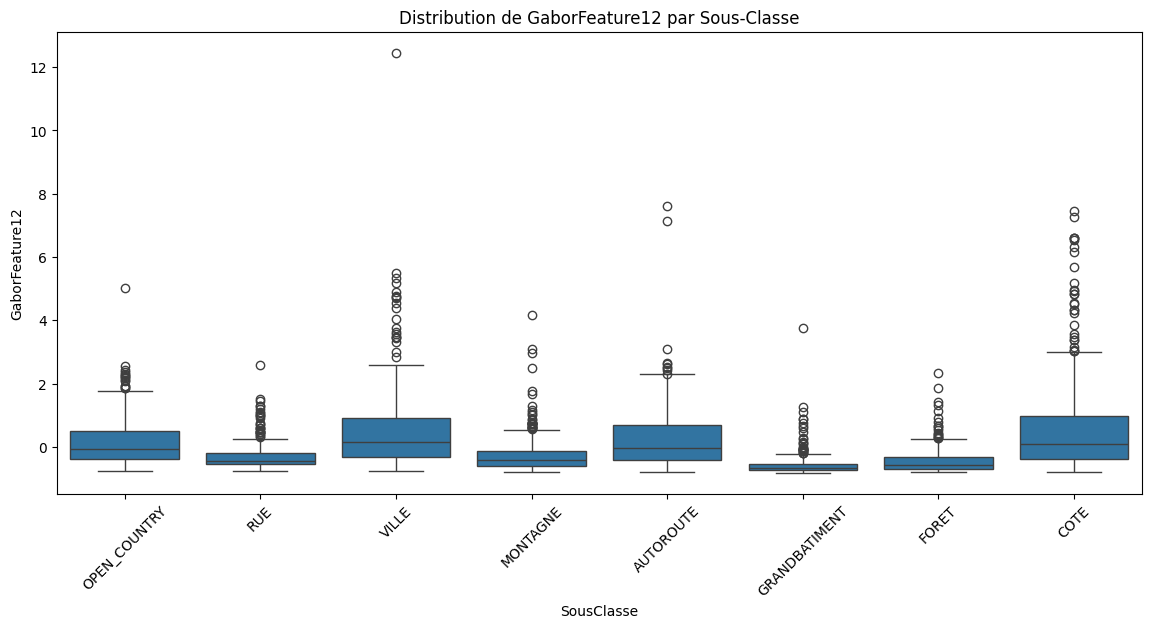

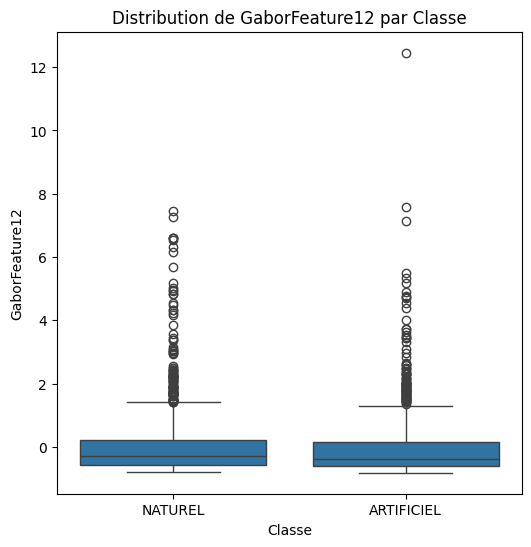

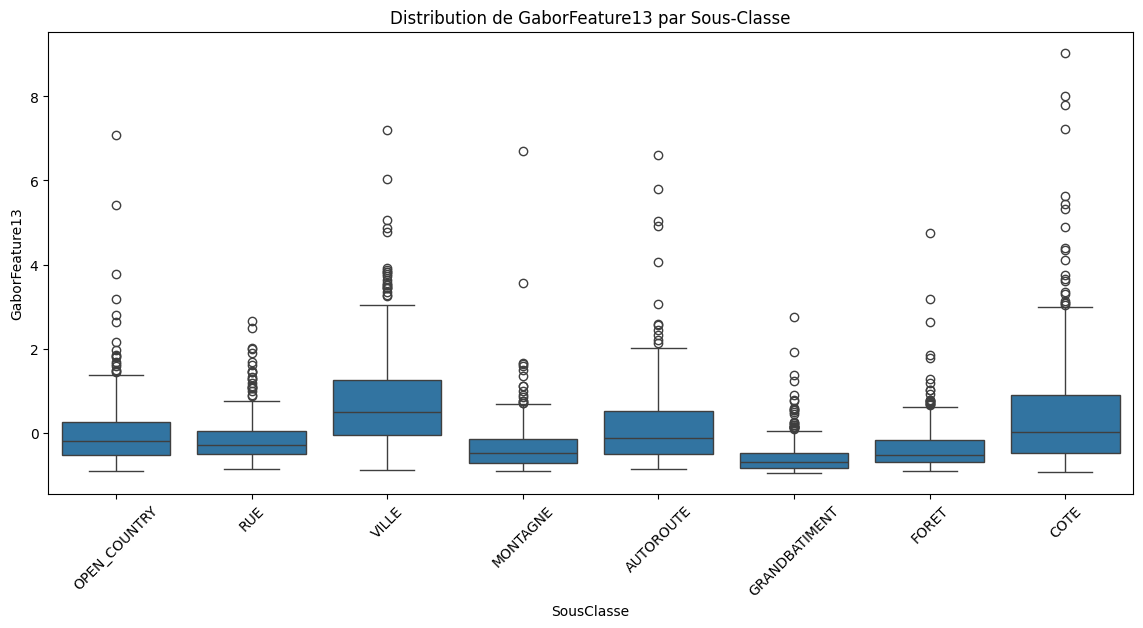

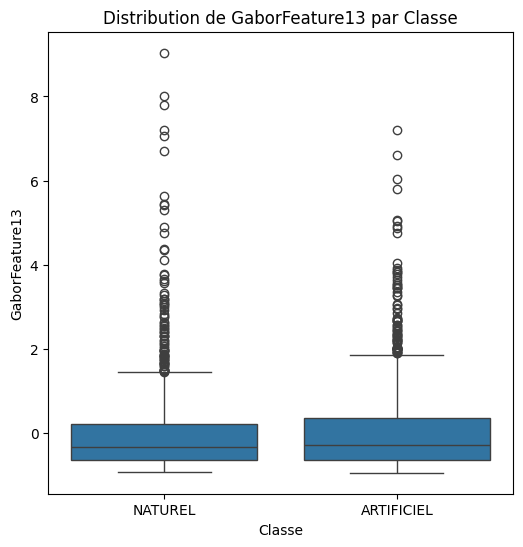

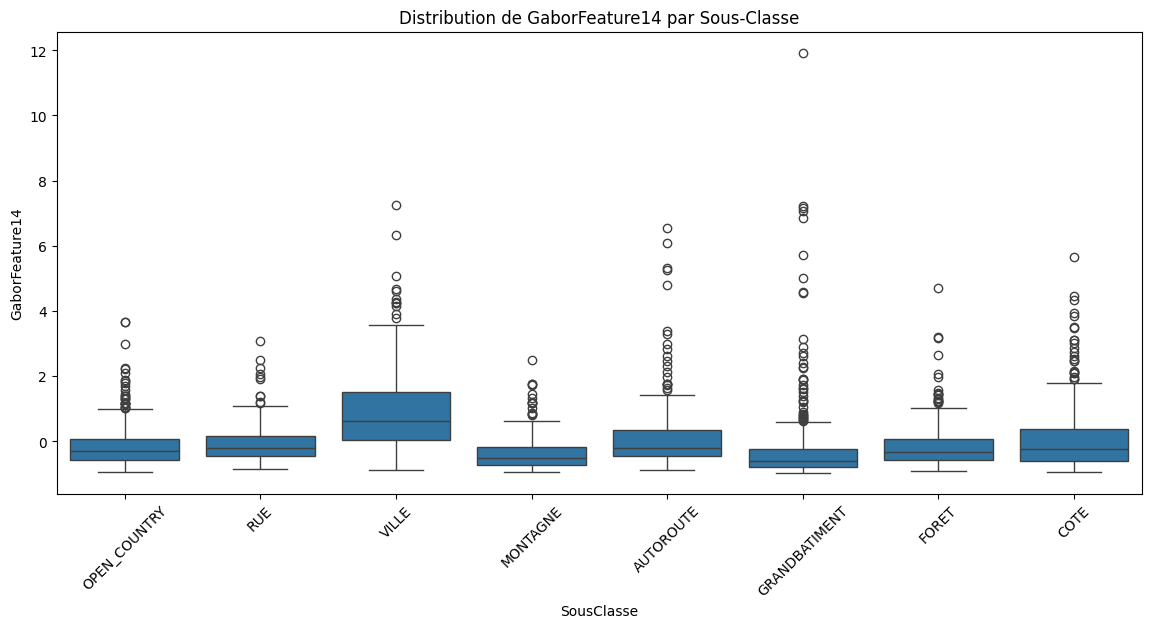

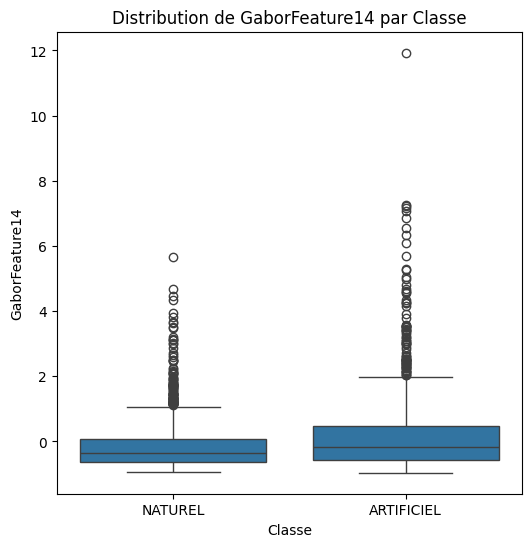

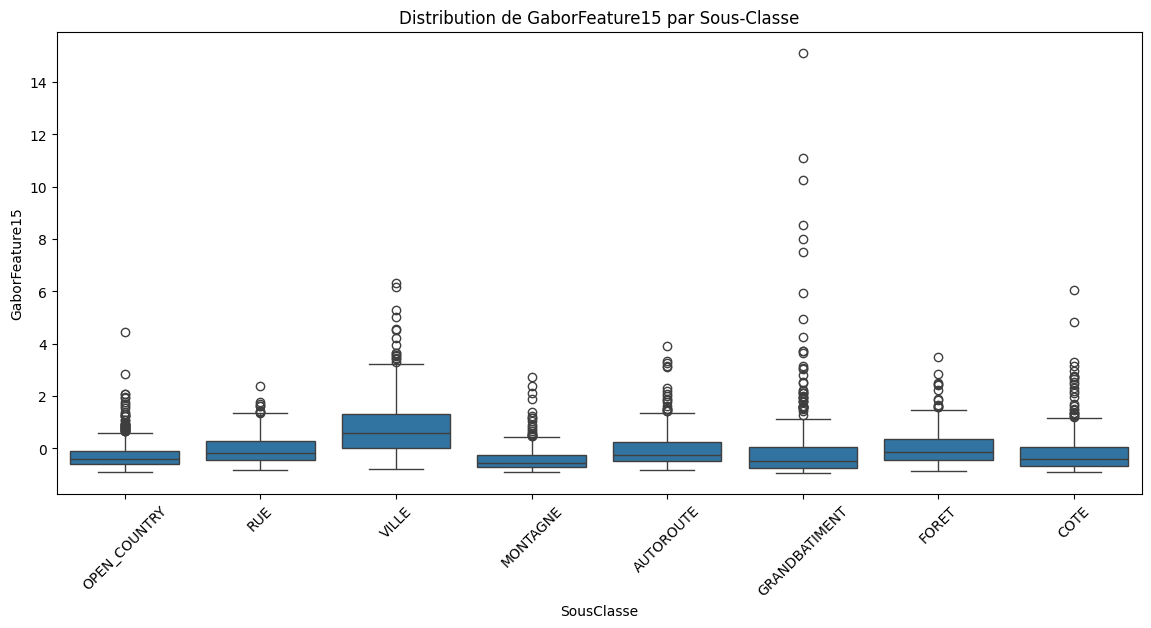

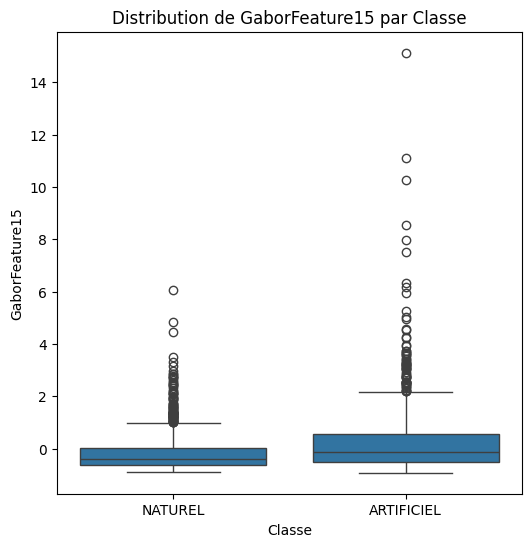

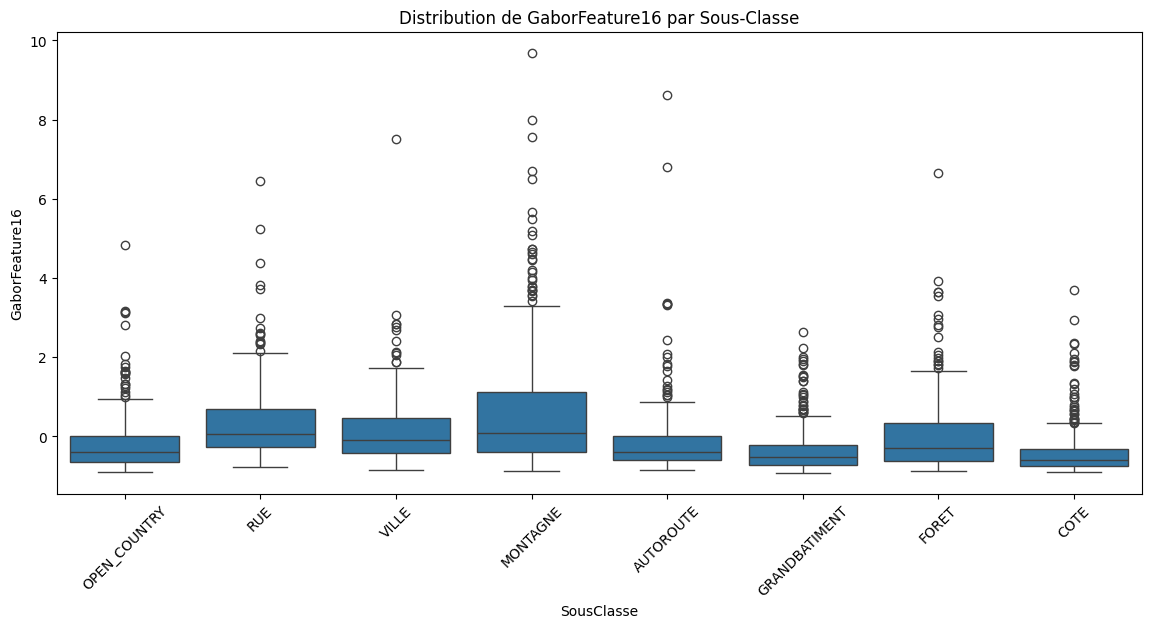

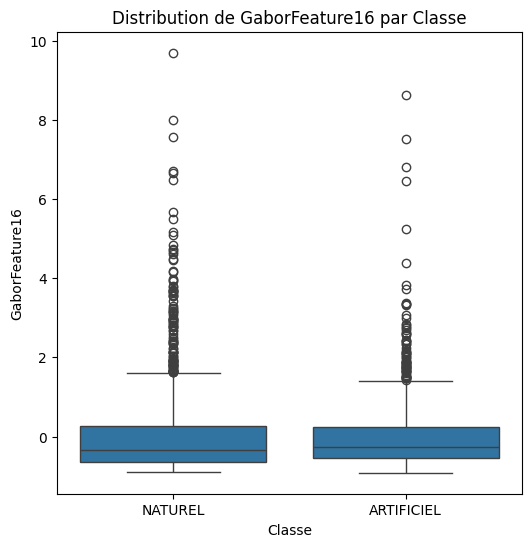

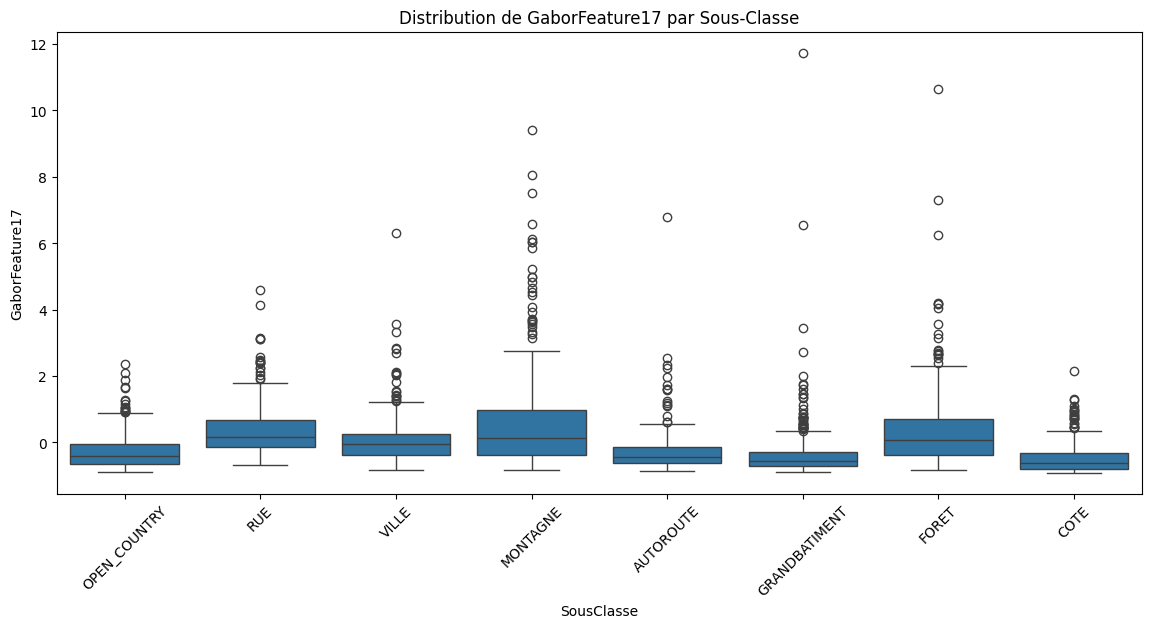

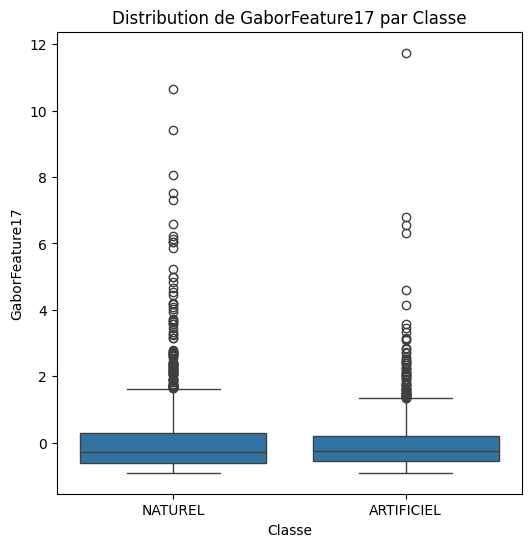

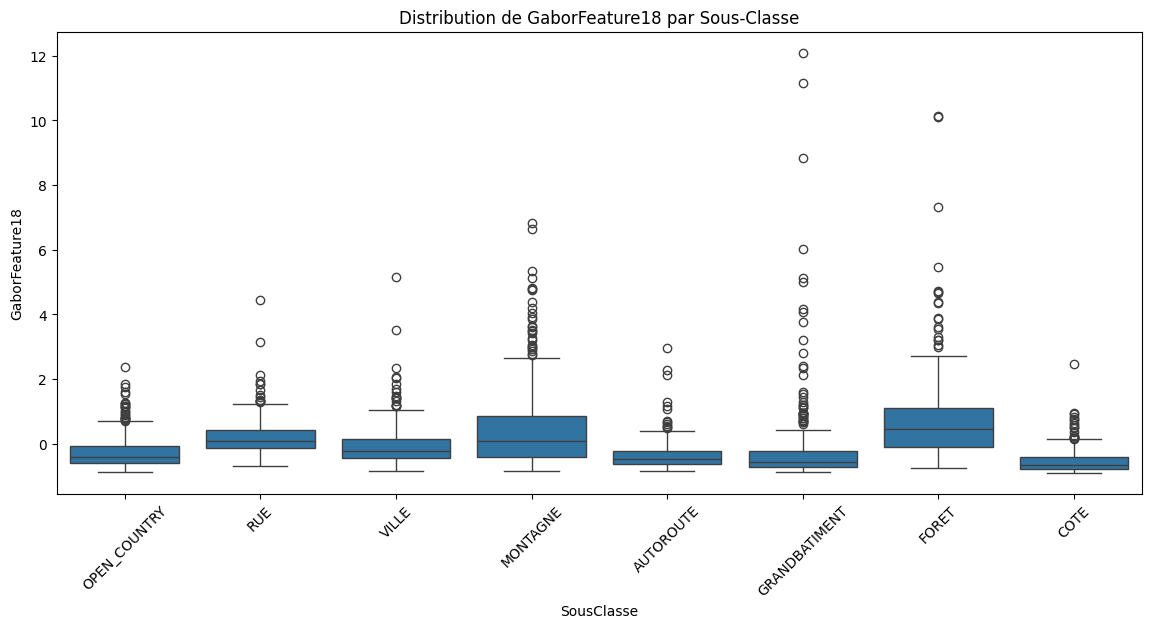

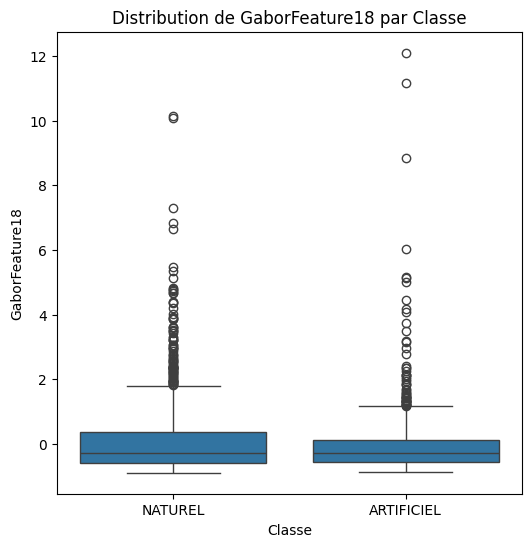

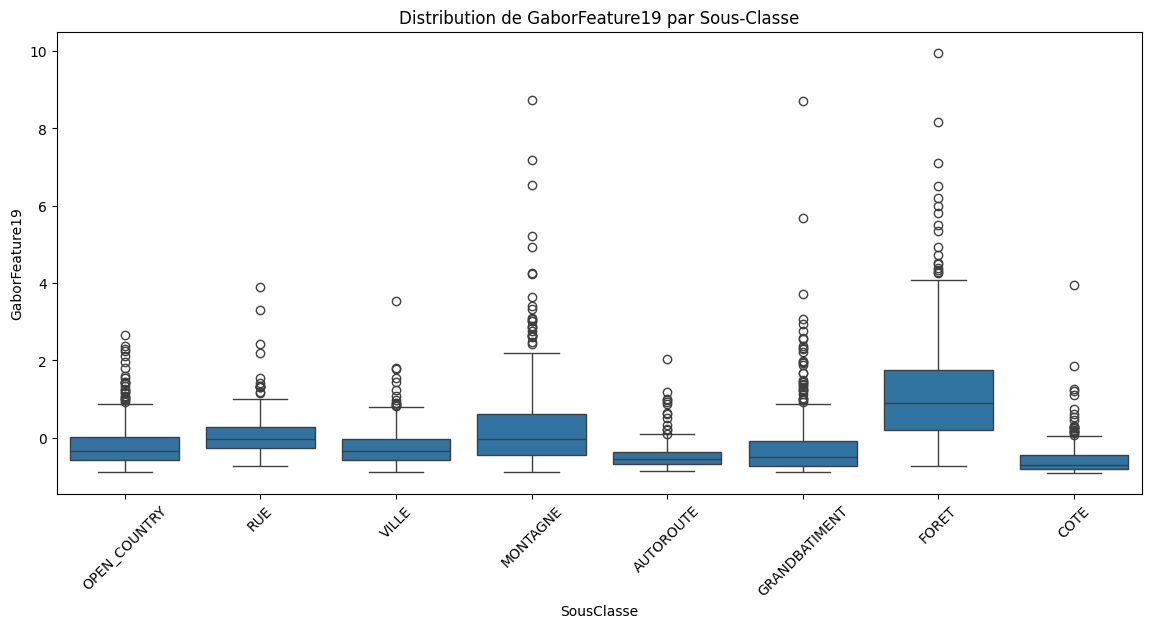

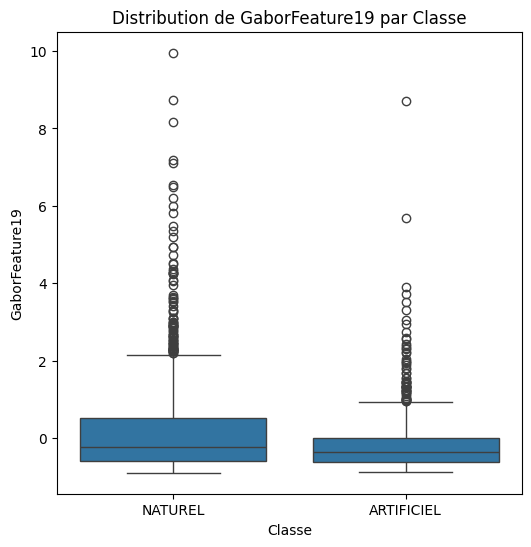

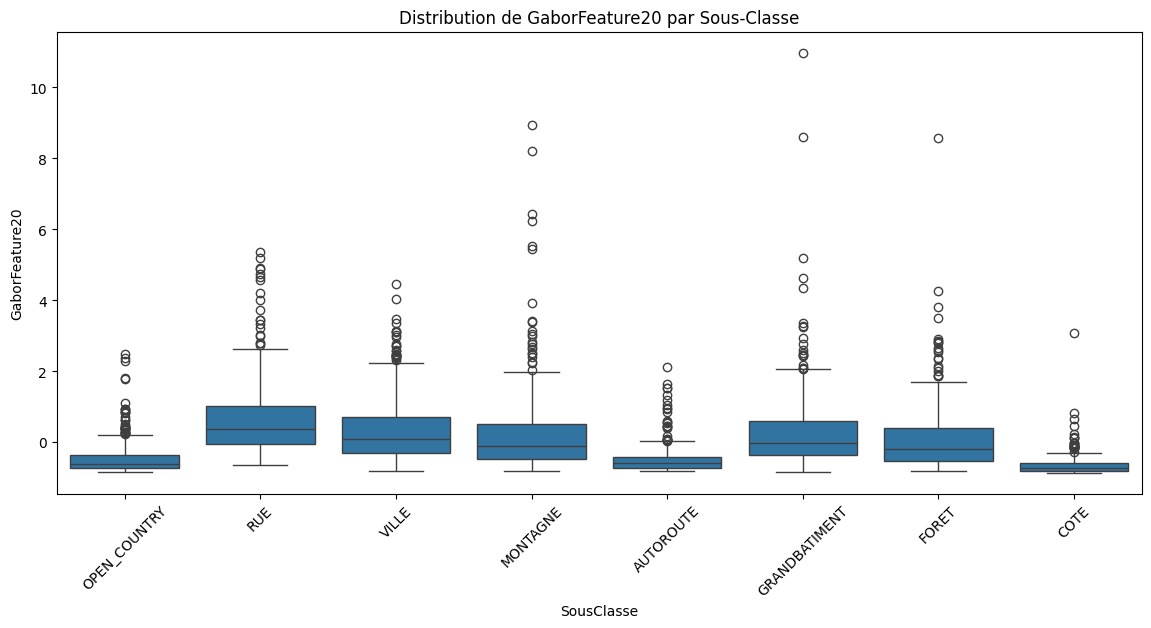

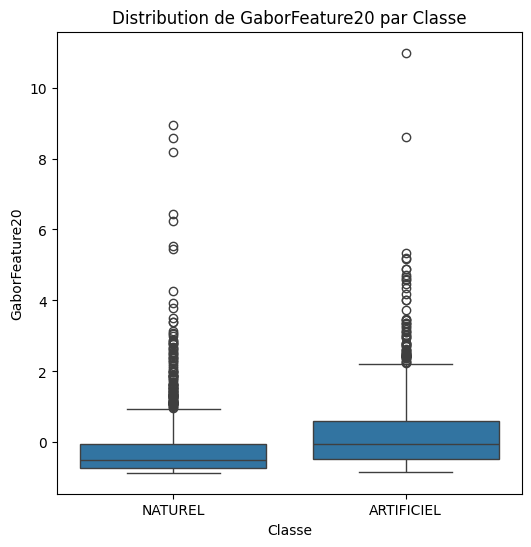

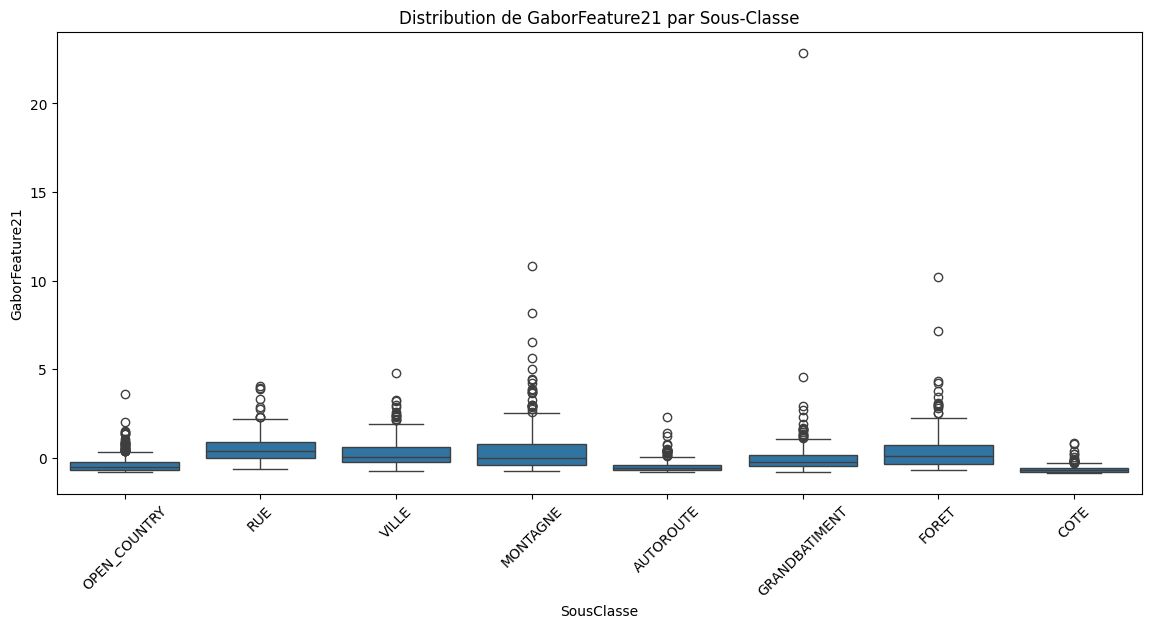

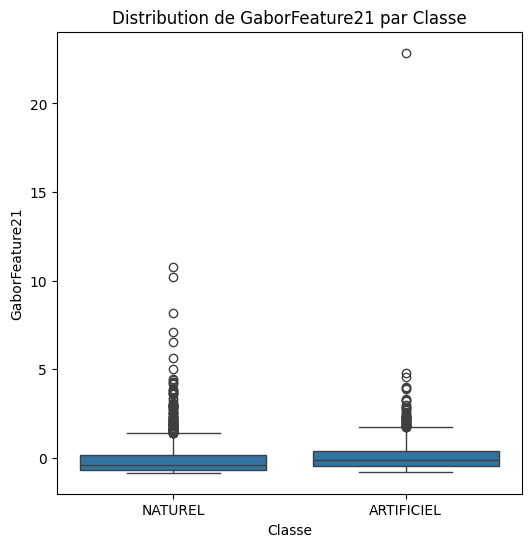

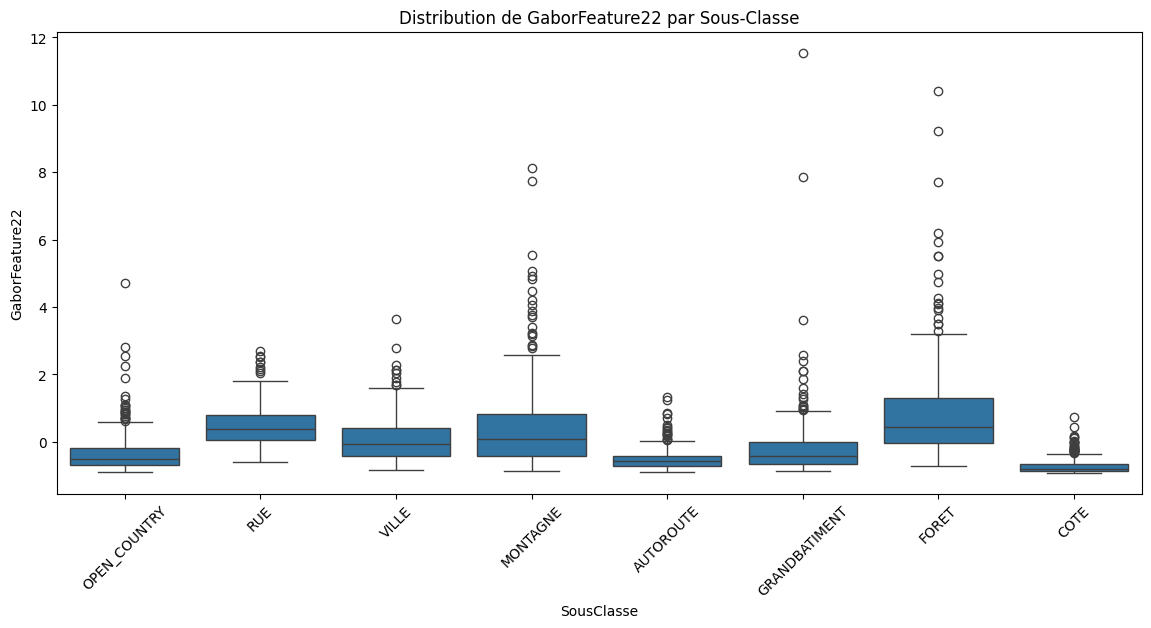

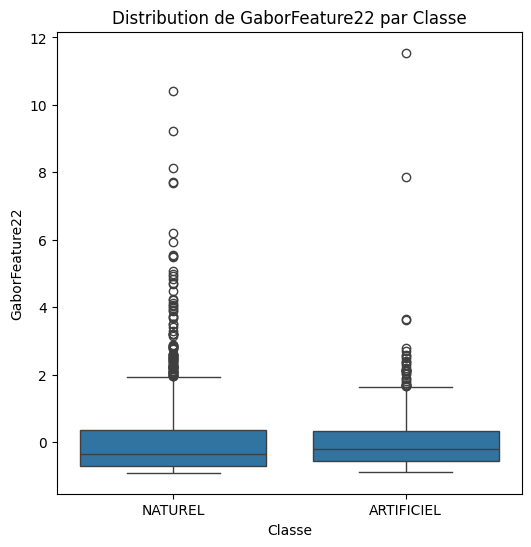

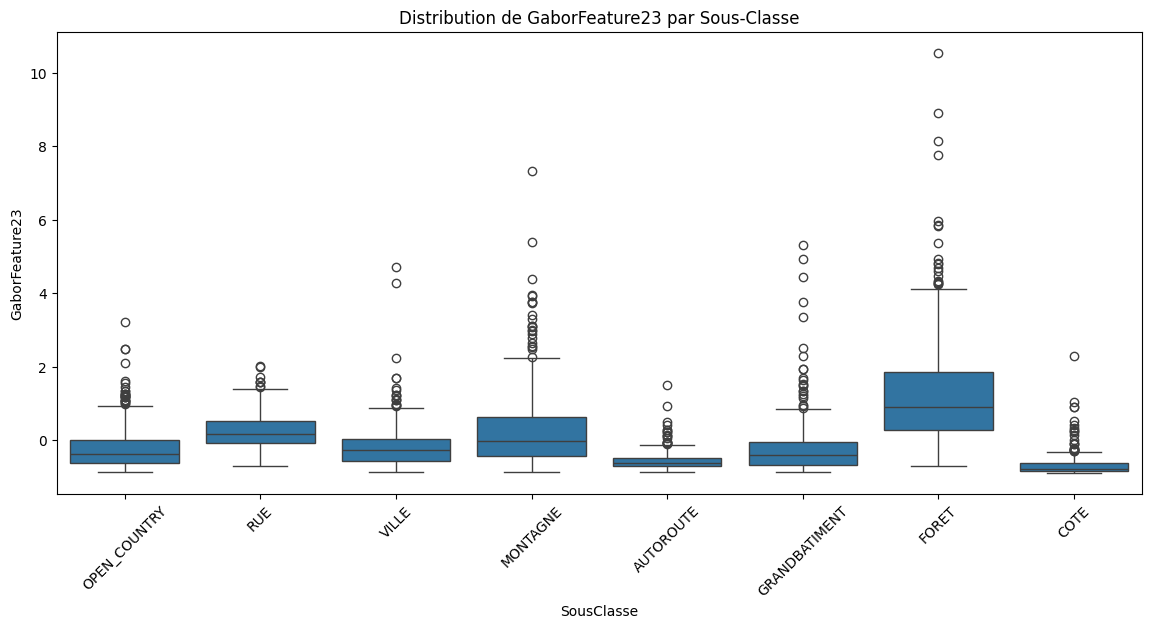

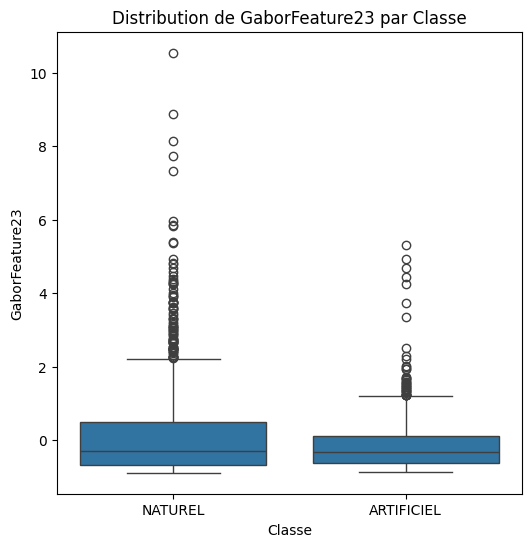

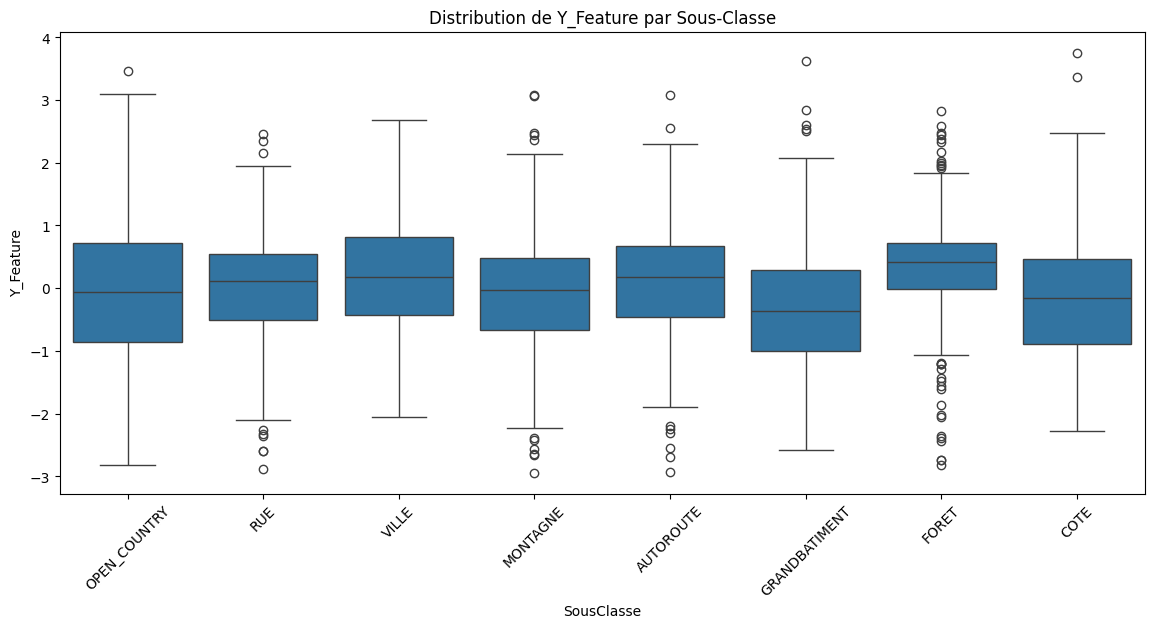

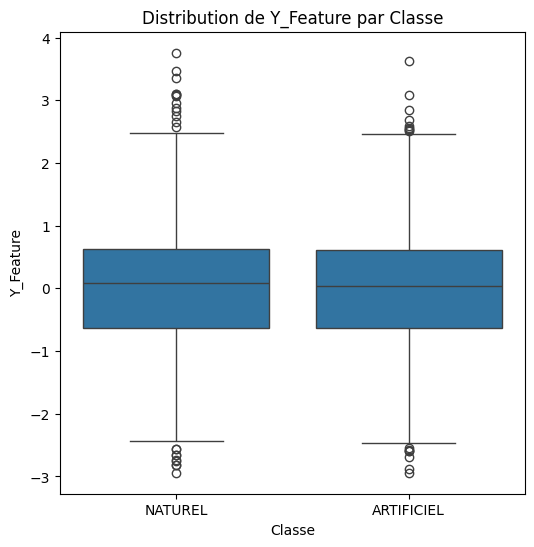

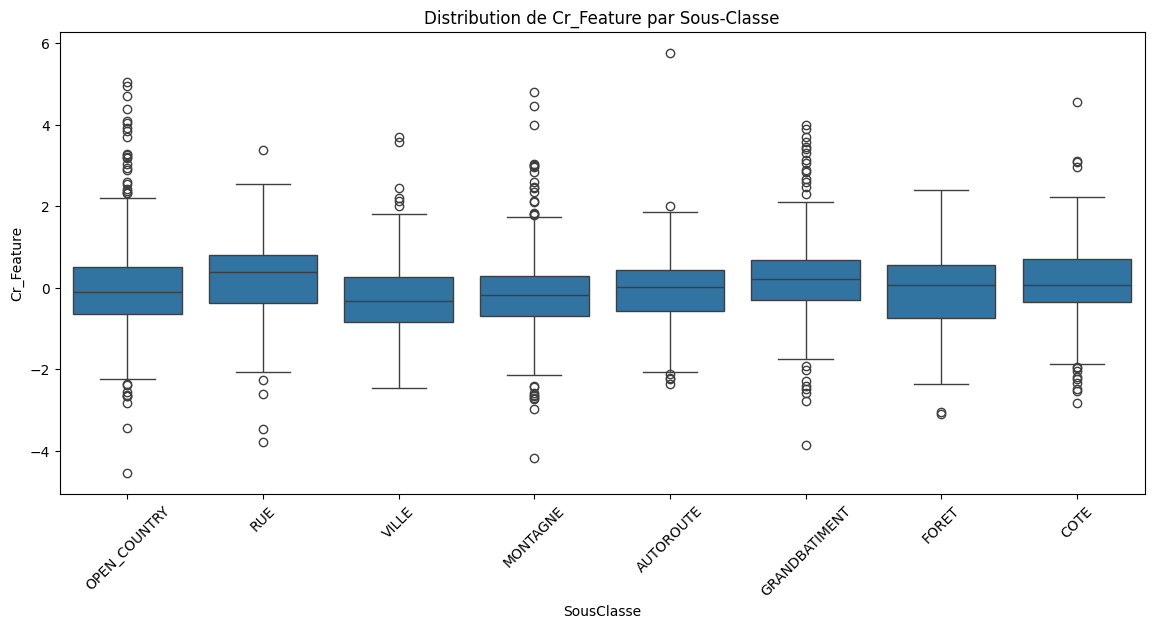

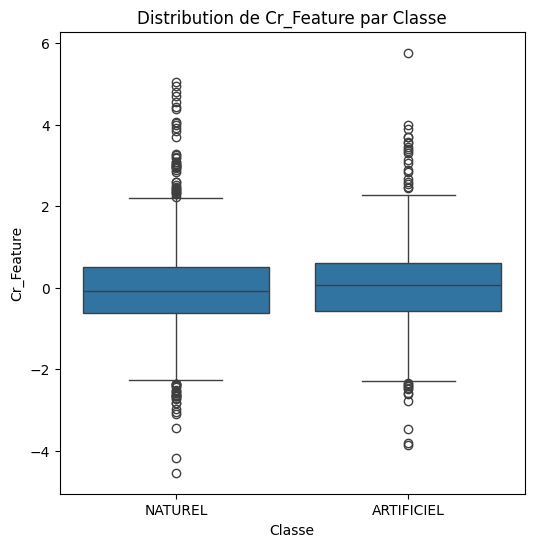

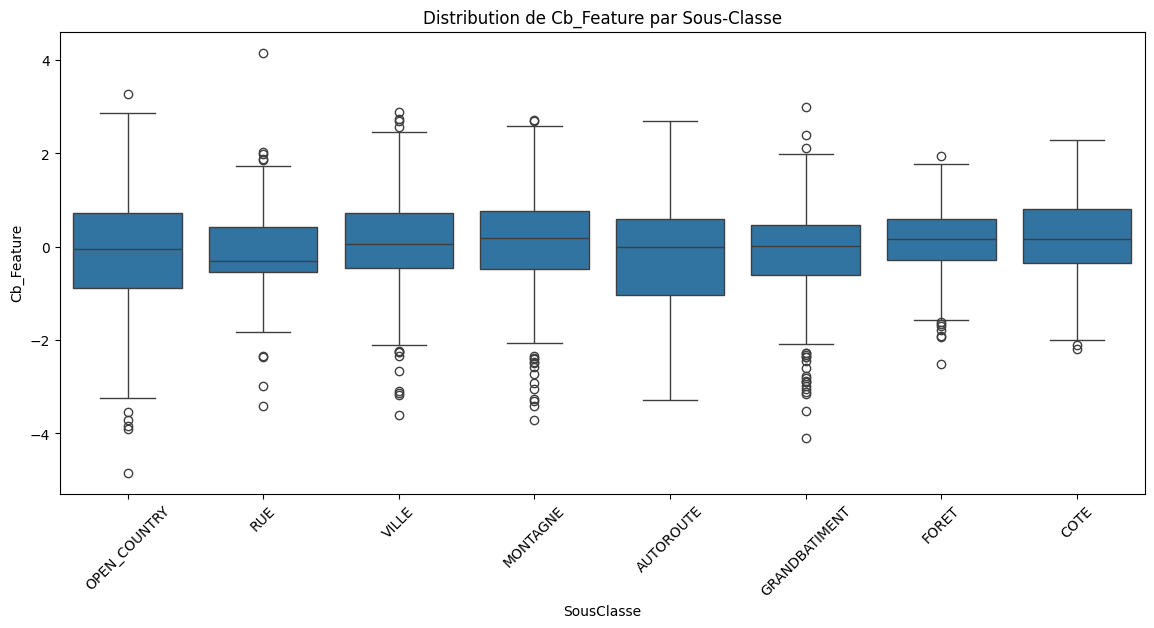

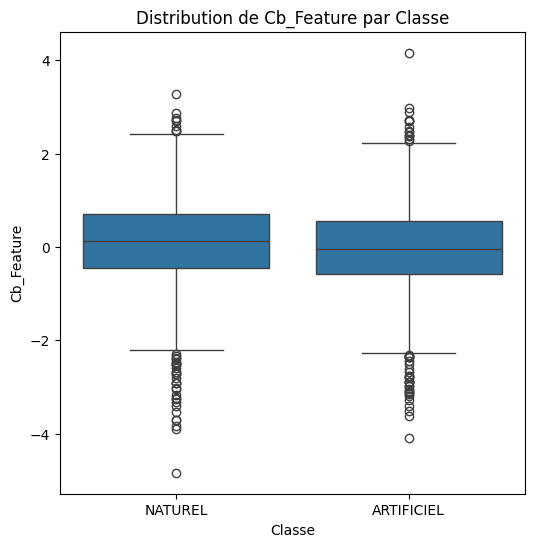

In [ ]:
features_cols = df.columns[3:]

for column in features_cols:
    # --- Par Sous-classes (8 catégories : Cote, Foret, etc.) ---
    plt.figure(figsize=(14, 6)) # Taille un peu plus grande pour lisibilité
    sns.boxplot(x="SousClasse", y=column, data=df)
    
    plt.title(f"Distribution de {column} par Sous-Classe")
    plt.xticks(rotation=45) # Rotation pour bien lire les noms des sous-classes
    plt.show()

    # --- Par Classes (2 catégories : Artificiel vs Naturel) ---
    plt.figure(figsize=(6, 6))
    sns.boxplot(x="Classe", y=column, data=df)
    
    plt.title(f"Distribution de {column} par Classe")
    plt.show()

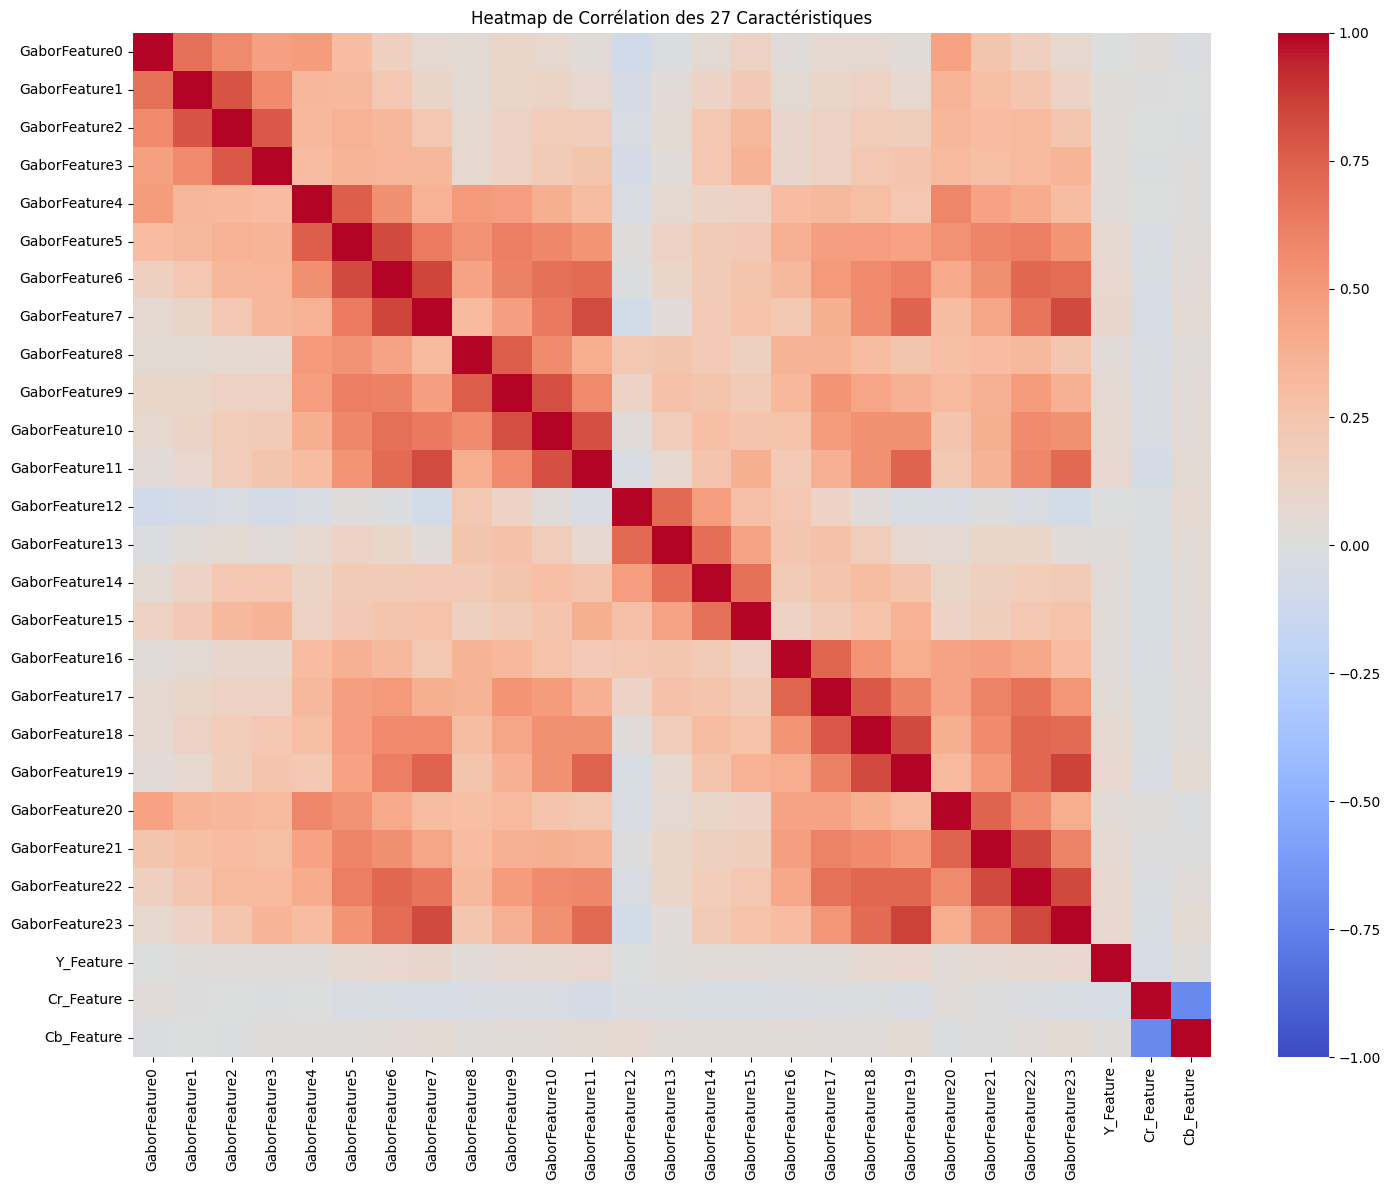

In [102]:
#On calcule les corrélations linéaires par couple de features
plt.figure(figsize=(15, 12))

sns.heatmap(
    df.iloc[:,3:].corr(),  
    annot=False,         
    cmap='coolwarm',     
    vmin=-1,             
    vmax=1               
)

plt.title('Heatmap de Corrélation des 27 Caractéristiques')
plt.tight_layout() 
plt.show()

On remarque que certaines (les plus proches) des 24 premières caractéristiques sont plutot très positivement corrélées entre elles et pour les 3 dernières seules Cr etCb son négativement corrélées

27


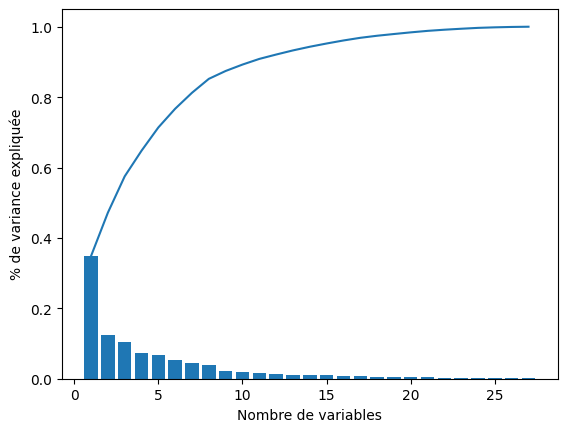

C:\Users\emman\AppData\Local\Temp\ipykernel_11240\2746462924.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_classes)
C:\Users\emman\AppData\Local\Temp\ipykernel_11240\2746462924.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centroids_27d = df_27d.groupby('classe').mean().values


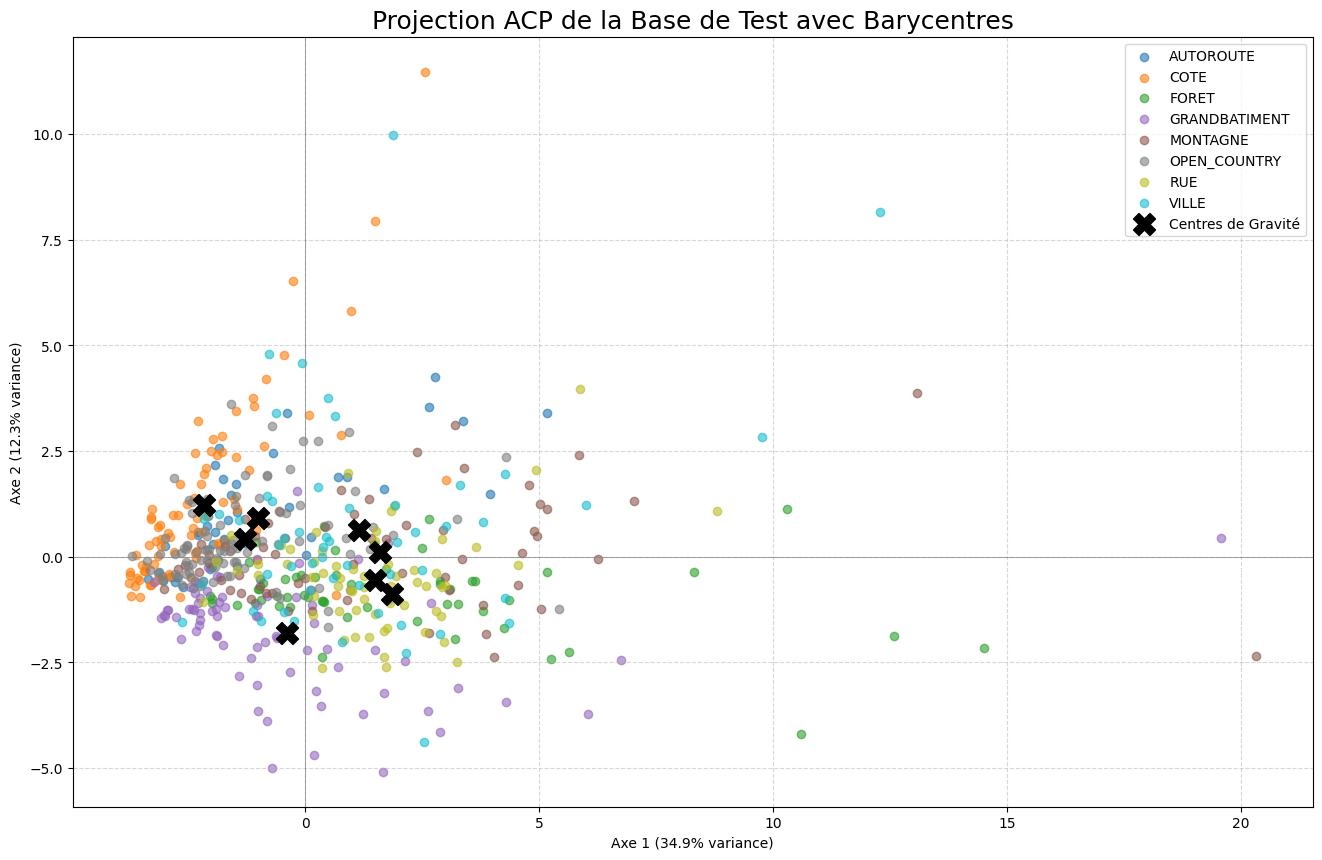

In [109]:
#ACP
pca = PCA()
X_test_pca = pca.fit_transform(X_test_scaled)

# Graphique du pouvoir de la variance expliquee
plt.figure() 
var_cum = [0]
for var in pca.explained_variance_ratio_:
    var_cum.append(var_cum[-1]+var)
var_cum.pop(0)
nb_axe_dis = len(X_test_pca[0])
print(nb_axe_dis)
plt.bar(np.arange(1, nb_axe_dis+1), pca.explained_variance_ratio_) 
plt.plot(np.arange(1,nb_axe_dis+1),var_cum)
plt.ylabel("% de variance expliquée") 
plt.xlabel("Nombre de variables") 
plt.show() 


#projection sur les deux premiers axes et tracé du nuage de points

y_test_names = le.inverse_transform(y_test) 
y_series = pd.Series(y_test_names).astype('category')
class_names = y_series.cat.categories
num_classes = len(class_names)

# Générer un jeu de couleurs
colors = plt.cm.get_cmap('tab10', num_classes)

#Calcul des Centres de Gravité
# On crée un DataFrame temporaire avec les données 27D scalées et les classes
df_27d = pd.DataFrame(X_test_scaled)
df_27d['classe'] = y_series.values

# Calculer la moyenne de chaque feature pour chaque classe
centroids_27d = df_27d.groupby('classe').mean().values

# Projeter ces centres 27D sur les 2 axes de l'ACP
centroids_2d = pca.transform(centroids_27d) 

#Création du Graphique
plt.figure(figsize=(16, 10))

# Boucle pour tracer chaque classe séparément
for i, class_name in enumerate(class_names):
    # Masque pour sélectionner les points de la classe courante
    mask = (y_series == class_name)
    
    plt.scatter(
        X_test_pca[mask, 0],    # Axe 1
        X_test_pca[mask, 1],    # Axe 2
        color=colors(i),
        label=class_name,
        alpha=0.6
    )

#Tracer les Centres de Gravité
plt.scatter(
    centroids_2d[:, 0], 
    centroids_2d[:, 1], 
    marker='X', 
    c='black', 
    s=250, 
    label='Centres de Gravité', 
    zorder=10
)

# Titre et Finitions
plt.title('Projection ACP de la Base de Test avec Barycentres', fontsize=18)
plt.xlabel(f'Axe 1 ({pca.explained_variance_ratio_[0]:.1%} variance)') 
plt.ylabel(f'Axe 2 ({pca.explained_variance_ratio_[1]:.1%} variance)') 
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)

plt.show()

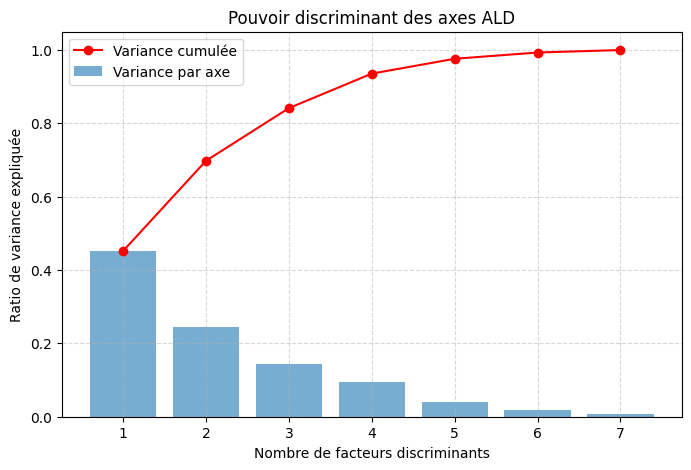

C:\Users\emman\AppData\Local\Temp\ipykernel_11240\2816232373.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_classes)
C:\Users\emman\AppData\Local\Temp\ipykernel_11240\2816232373.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centroids_27d = df_27d.groupby('classe').mean().values


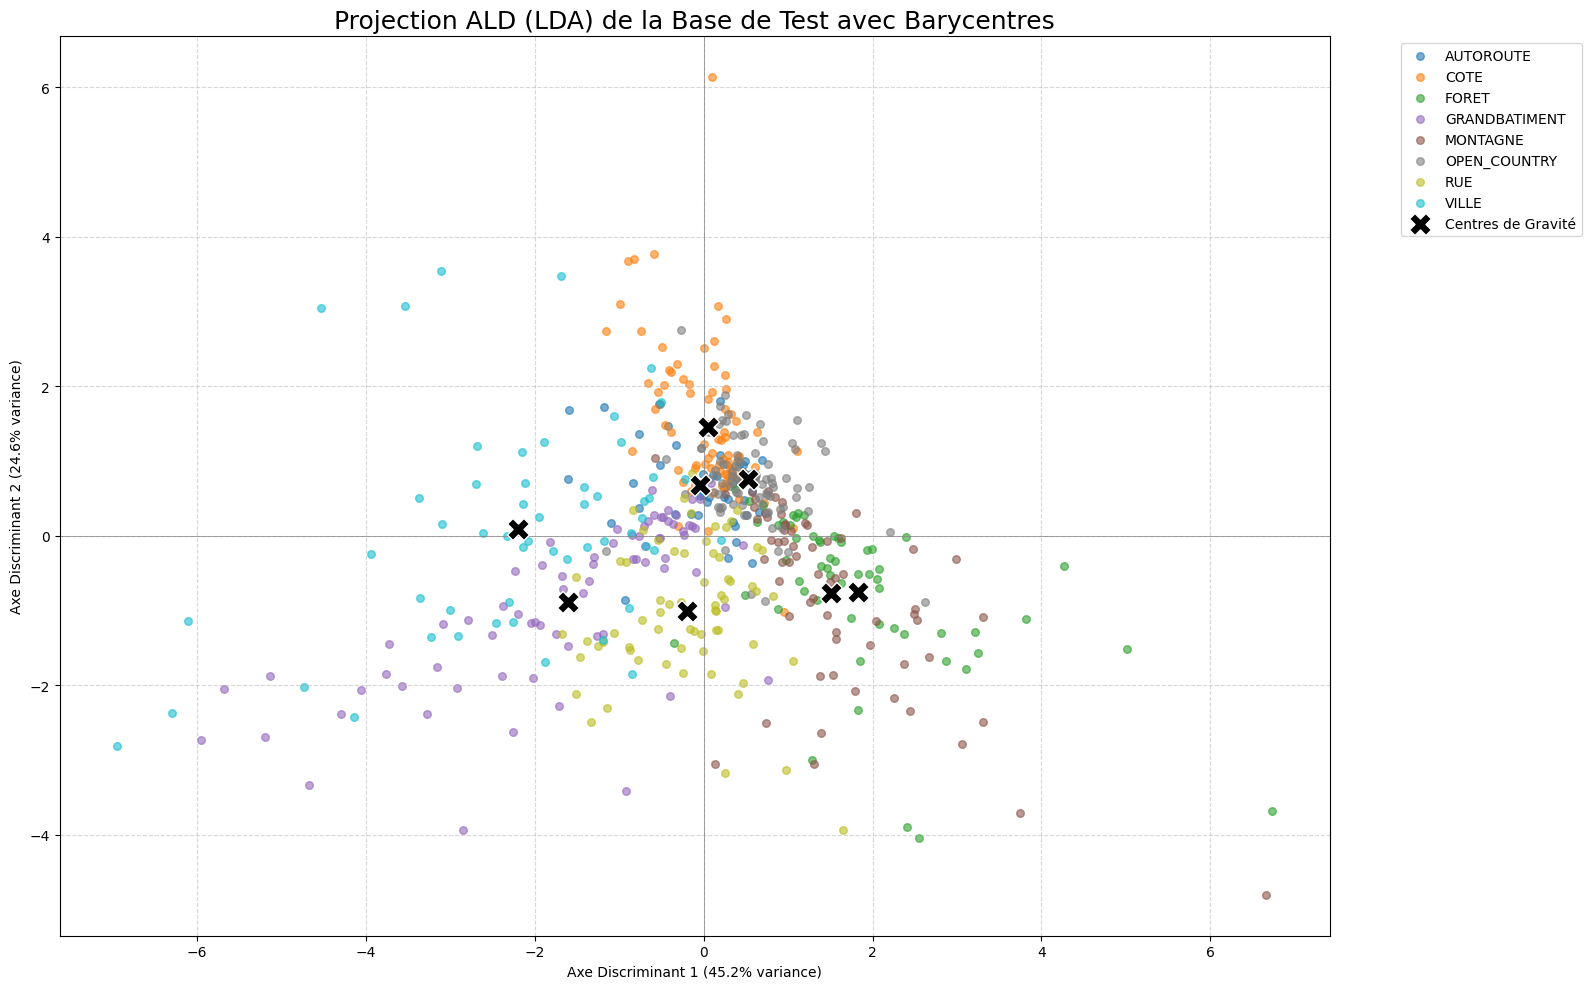

In [105]:
# ALD
ald = LDA()
X_test_ald = ald.fit_transform(X_test_scaled, y_test) 
 
#Graphique du Pouvoir Discriminant
plt.figure(figsize=(8, 5))
explained_variance = ald.explained_variance_ratio_
cum_variance = np.cumsum(explained_variance)
nb_axe_dis = len(explained_variance)

plt.bar(np.arange(1, nb_axe_dis+1), explained_variance, alpha=0.6, label='Variance par axe')
plt.plot(np.arange(1, nb_axe_dis+1), cum_variance, marker='o', color='red', label='Variance cumulée')
plt.ylabel("Ratio de variance expliquée")
plt.xlabel("Nombre de facteurs discriminants")
plt.title("Pouvoir discriminant des axes ALD")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#Projection sur les 2 premiers axes discriminants

plt.figure(figsize=(16,10))

# Récupération des vrais noms de classes pour l'affichage
y_test_names = le.inverse_transform(y_test) 
y_series = pd.Series(y_test_names).astype('category')
class_names = y_series.cat.categories
num_classes = len(class_names)

colors = plt.cm.get_cmap('tab10', num_classes)

#Calcul des Centres de Gravité
# On crée un DataFrame temporaire avec les données 27D du test
df_27d = pd.DataFrame(X_test_scaled)
df_27d['classe'] = y_series.values

# Calculer la moyenne en 27 dimensions pour chaque classe
centroids_27d = df_27d.groupby('classe').mean().values

# Projeter ces centres sur les axes de l'ALD
centroids_2d = ald.transform(centroids_27d)

# Boucle pour chaque classe
for i, class_name in enumerate(class_names):
    mask = (y_series == class_name)
    plt.scatter(
        X_test_ald[mask, 0],    # Axe ALD 1
        X_test_ald[mask, 1],    # Axe ALD 2
        color=colors(i),
        label=class_name,
        alpha=0.6,
        s=30
    )

# Tracer les Centres de Gravité
plt.scatter(
    centroids_2d[:, 0], 
    centroids_2d[:, 1], 
    marker='X', 
    c='black', 
    s=250, 
    label='Centres de Gravité', 
    zorder=10,
    edgecolors='white'
)

# Titres et légendes
plt.title('Projection ALD (LDA) de la Base de Test avec Barycentres', fontsize=18)
plt.xlabel(f'Axe Discriminant 1 ({ald.explained_variance_ratio_[0]:.1%} variance)') 
plt.ylabel(f'Axe Discriminant 2 ({ald.explained_variance_ratio_[1]:.1%} variance)') 
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
plt.tight_layout()

plt.show()

PARTIE MACHINE LEARNING

Optimisation SVM (Balanced Accuracy)...
--- Top 5 Configurations pour SVM ---
 param_C param_decision_function_shape param_kernel  mean_score  margin_error  ci_lower  ci_upper
    10.0                           ovr       linear    0.695856      0.023795  0.672061  0.719651
    10.0                           ovo       linear    0.695856      0.023795  0.672061  0.719651
   100.0                           ovo       linear    0.694456      0.024953  0.669503  0.719409
   100.0                           ovr       linear    0.694456      0.024953  0.669503  0.719409
     1.0                           ovr       linear    0.694381      0.026962  0.667419  0.721343
------------------------------------------------------------


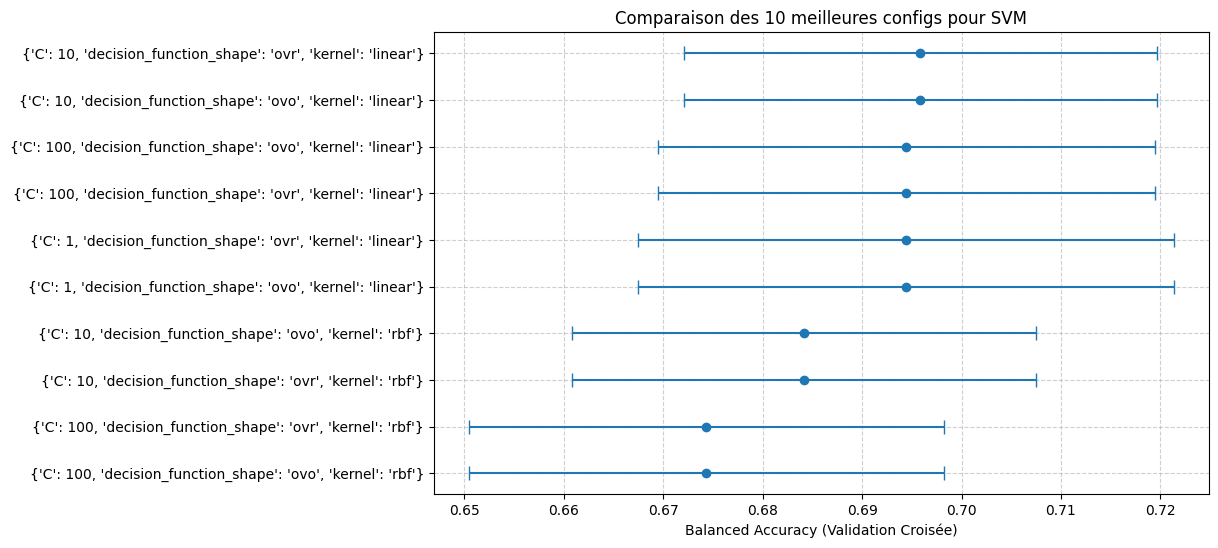


Optimisation MLP (Balanced Accuracy)...
--- Top 5 Configurations pour MLP ---
param_activation param_hidden_layer_sizes  param_max_iter  mean_score  margin_error  ci_lower  ci_upper
        logistic                   (100,)            1000    0.718904      0.025170  0.693734  0.744074
        logistic                    (50,)            1000    0.716451      0.023212  0.693239  0.739662
            relu                  (1000,)            1000    0.712301      0.011397  0.700905  0.723698
        logistic                  (1000,)            1000    0.711710      0.014976  0.696733  0.726686
            relu                   (200,)            1000    0.708867      0.013450  0.695416  0.722317
------------------------------------------------------------


c:\Users\emman\OneDrive\Desktop\IESE 5\Machine Learning\projet2\.env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


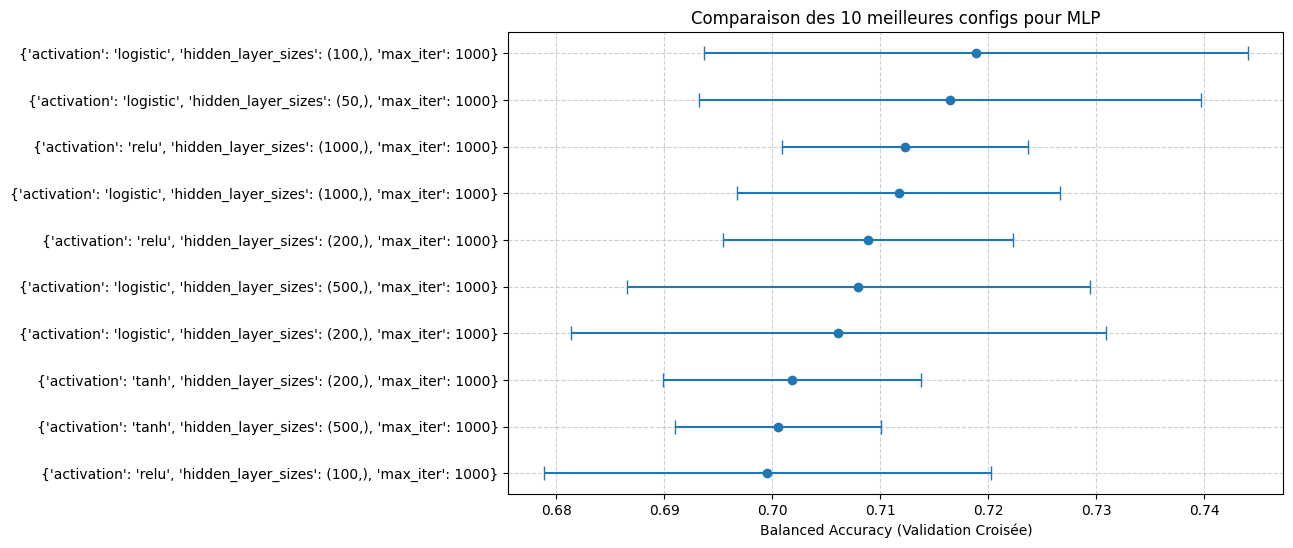

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Instanciation des modèles de base
mlp = MLPClassifier()
svm = SVC()

#Fonction pour analyser les résultats du GridSearch
def analyze_grid_results(grid_search, model_name):
    # Récupération des résultats sous forme de DataFrame
    results = pd.DataFrame(grid_search.cv_results_)
    
    # On s'intéresse au score moyen et à l'écart-type sur les plis de validation
    k_folds = grid_search.n_splits_
    
    results['mean_score'] = results['mean_test_score']
    results['std_score'] = results['std_test_score']
    
    # Calcul de la marge d'erreur (IC à 95%)
    results['margin_error'] = 1.96 * (results['std_score'] / np.sqrt(k_folds))
    results['ci_lower'] = results['mean_score'] - results['margin_error']
    results['ci_upper'] = results['mean_score'] + results['margin_error']
    
    # Tri par meilleur score moyen
    results = results.sort_values(by='mean_score', ascending=False)
    
    # Affichage des 5 meilleures configurations
    print(f"--- Top 5 Configurations pour {model_name} ---")
    cols_params = [col for col in results.columns if 'param_' in col]
    display_cols = cols_params + ['mean_score', 'margin_error', 'ci_lower', 'ci_upper']
    print(results[display_cols].head(5).to_string(index=False))
    print("-" * 60)
    
    # Visualisation des meilleures configs
    top_n = 10
    top_results = results.head(top_n)
    
    plt.figure(figsize=(10, 6))
    # On crée des labels lisibles pour les paramètres
    labels = [str(p) for p in top_results['params']]
    
    plt.errorbar(x=top_results['mean_score'], y=np.arange(top_n), 
                 xerr=top_results['margin_error'], fmt='o', capsize=5, label='Mean Score ± IC 95%')
    
    plt.yticks(np.arange(top_n), labels)
    plt.xlabel('Balanced Accuracy (Validation Croisée)')
    plt.title(f'Comparaison des {top_n} meilleures configs pour {model_name}')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.gca().invert_yaxis() # On met ici le meilleur en haut
    plt.show()
    
    return results.iloc[0]['params'], grid_search.best_estimator_

#Lancement des GridSearch avec "balanced_accuracy

# SVM
print("Optimisation SVM (Balanced Accuracy)...")
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    "kernel": ['linear', 'poly', 'rbf', 'sigmoid'],
    'decision_function_shape': ['ovo', 'ovr'] 
}

grid_svm = GridSearchCV(svm, param_grid_svm, cv=5, n_jobs=-1, scoring='balanced_accuracy')
grid_svm.fit(X_train_scaled, y_train)

best_params_svm, best_svm_model = analyze_grid_results(grid_svm, "SVM")

# MLP
print("\nOptimisation MLP (Balanced Accuracy)...")
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (200,), (500,), (1000,)],
    'activation': ['identity', 'logistic', 'tanh', 'relu'],
    'max_iter': [1000]
}
grid_mlp = GridSearchCV(mlp, param_grid_mlp, cv=5, n_jobs=-1, scoring='balanced_accuracy')
grid_mlp.fit(X_train_scaled, y_train)

best_params_mlp, best_mlp_model = analyze_grid_results(grid_mlp, "MLP")

1. Pour le MPL : 
- On remarque que les premiers 8 premiers modèles ont des accuracy avec des intervalles de confiance qui se chevauchent et dans ce cas nous allons choisir le modèle le plus simple cad logistic 50
2. Pour le SVM : 
- On remarque que les intervalles de confiance se chevauchent ce qui veut dire que aucune de ces configurations n'est statitiquement meilleure que les autres nous allons choisir celui qui est le plus simple cad : linear c=10 ovr. 

In [115]:
# Cellule 5 : Résultats finaux ML Classique
print("--- Rapport SVM (Test) ---")
y_pred_svm = grid_svm.predict(X_test_scaled)
print(classification_report(y_test, y_pred_svm, target_names=class_names))

print("--- Rapport MLP (Test) ---")
y_pred_mlp = grid_mlp.predict(X_test_scaled)
print(classification_report(y_test, y_pred_mlp, target_names=class_names))

--- Rapport SVM (Test) ---
               precision    recall  f1-score   support

    AUTOROUTE       0.56      0.52      0.54        44
         COTE       0.74      0.82      0.78        83
        FORET       0.75      0.79      0.77        57
GRANDBATIMENT       0.82      0.83      0.82        75
     MONTAGNE       0.76      0.85      0.80        65
 OPEN_COUNTRY       0.73      0.69      0.71        93
          RUE       0.76      0.61      0.68        67
        VILLE       0.73      0.74      0.73        54

     accuracy                           0.74       538
    macro avg       0.73      0.73      0.73       538
 weighted avg       0.74      0.74      0.74       538

--- Rapport MLP (Test) ---
               precision    recall  f1-score   support

    AUTOROUTE       0.63      0.43      0.51        44
         COTE       0.77      0.80      0.78        83
        FORET       0.78      0.81      0.79        57
GRANDBATIMENT       0.81      0.83      0.82        75
     MO

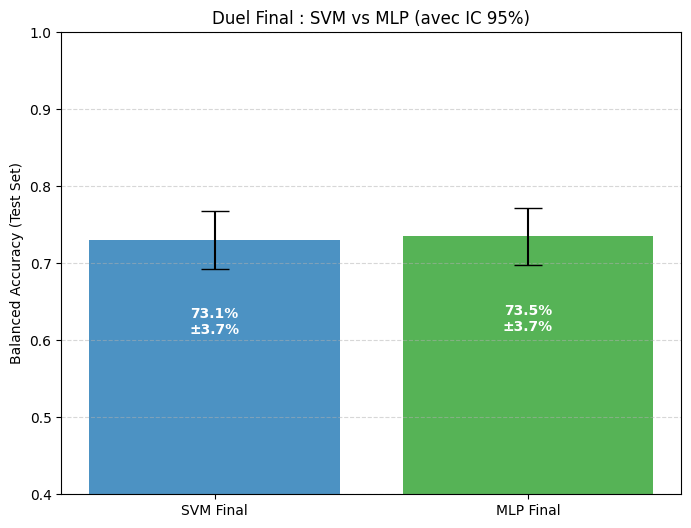

--------------------------------------------------
CONCLUSION COMPARAISON FINAL
--------------------------------------------------
SVM : 73.06% ± 3.75%
MLP : 73.48% ± 3.73%


In [116]:
#Comparaison Finale sur la Base de Test

def compute_test_metrics_ci(model, X, y_true, name):
    # Prédiction
    y_pred = model.predict(X)
    
    #on garde la balanced_accuracy comme score pour rester cohérent
    score = balanced_accuracy_score(y_true, y_pred)
    
    # Intervalle de confiance
    n = len(y_true)
    margin = 1.96 * math.sqrt((score * (1 - score)) / n)
    
    return score, margin

# Calculs
acc_svm, err_svm = compute_test_metrics_ci(best_svm_model, X_test_scaled, y_test, "SVM Final")
acc_mlp, err_mlp = compute_test_metrics_ci(best_mlp_model, X_test_scaled, y_test, "MLP Final")

# Affichage Graphique
plt.figure(figsize=(8, 6))
models = ['SVM Final', 'MLP Final']
x_pos = np.arange(len(models))
accuracies = [acc_svm, acc_mlp]
errors = [err_svm, err_mlp]

bars = plt.bar(x_pos, accuracies, yerr=errors, align='center', alpha=0.8, ecolor='black', capsize=10, color=['#1f77b4', '#2ca02c'])
plt.ylabel('Balanced Accuracy (Test Set)')
plt.xticks(x_pos, models)
plt.title('Duel Final : SVM vs MLP (avec IC 95%)')
plt.ylim(0.4, 1.0) # Ajuster selon les scores
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Ajout des étiquettes de valeur sur les barres
for bar, acc, err in zip(bars, accuracies, errors):
    plt.text(bar.get_x() + bar.get_width()/2, acc - err - 0.05, 
             f"{acc:.1%}\n±{err:.1%}", 
             ha='center', va='top', color='white', fontweight='bold')

plt.show()

# Conclusion
print("-" * 50)
print("CONCLUSION COMPARAISON FINAL")
print("-" * 50)
print(f"SVM : {acc_svm:.2%} ± {err_svm:.2%}")
print(f"MLP : {acc_mlp:.2%} ± {err_mlp:.2%}")


On remarque que les deux modèles donnent des résultats statistiquement équivalent aucun n'est meilleur nous allons choisir le SVM

Calcul des courbes d'apprentissage en cours...
Cela peut prendre une minute car on entraîne plusieurs fois les modèles...
   -> Traitement du SVM...
   -> Traitement du MLP...


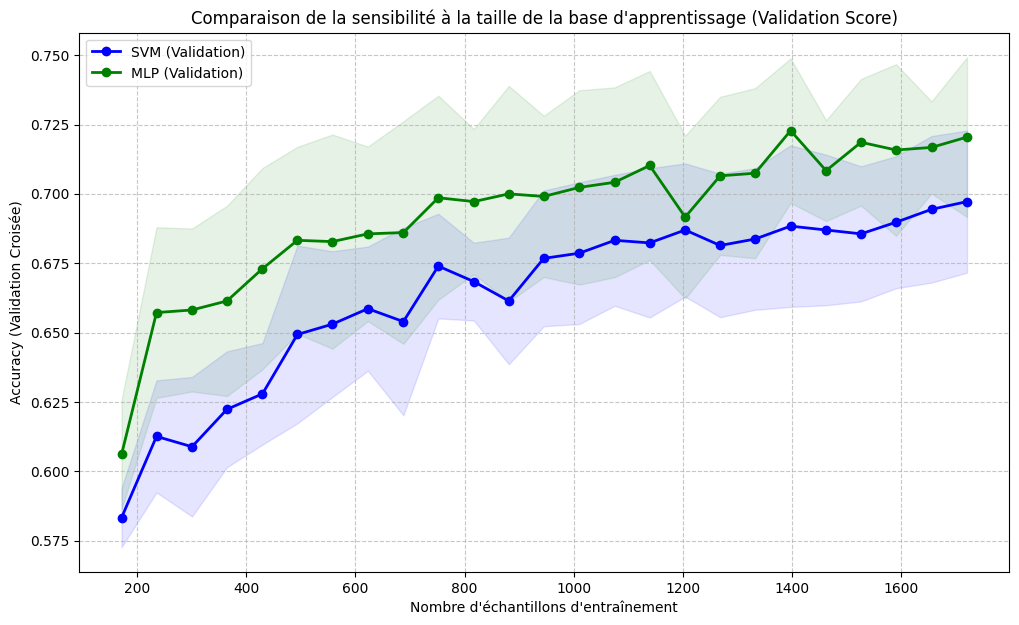

----------------------------------------
ANALYSE DE LA SENSIBILITÉ
----------------------------------------
Gain SVM (10% -> 100% données) : +11.4%
Gain MLP (10% -> 100% données) : +11.4%

Le MLP finit plus haut : Il a une meilleure capacité d'apprentissage sur ce volume de données.
Note : Le MLP semble saturer (plateau), ajouter des données n'aiderait pas beaucoup plus.


In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

#Récupération des meilleurs modèles
# On utilise les meilleurs estimateurs trouvés par le GridSearch
svm_model = grid_svm.best_estimator_
mlp_model = grid_mlp.best_estimator_

print("Calcul des courbes d'apprentissage en cours...")
print("Cela peut prendre une minute car on entraîne plusieurs fois les modèles...")

# 2. Paramètres de la courbe
train_sizes_pct = np.linspace(0.1, 1.0, 25)

#Calcul pour le SVM
print("   -> Traitement du SVM...")
train_sizes, train_scores_svm, val_scores_svm = learning_curve(
    svm_model, X_train_scaled, y_train, 
    train_sizes=train_sizes_pct, cv=5, n_jobs=-1, scoring='accuracy'
)
# Moyennes SVM
svm_val_mean = np.mean(val_scores_svm, axis=1)
svm_val_std = np.std(val_scores_svm, axis=1)

#Calcul pour le MLP
print("   -> Traitement du MLP...")
train_sizes, train_scores_mlp, val_scores_mlp = learning_curve(
    mlp_model, X_train_scaled, y_train, 
    train_sizes=train_sizes_pct, cv=5, n_jobs=-1, scoring='accuracy'
)
# Moyennes MLP
mlp_val_mean = np.mean(val_scores_mlp, axis=1)
mlp_val_std = np.std(val_scores_mlp, axis=1)

#Visualisation Graphique
plt.figure(figsize=(12, 7))

# Trace SVM en Bleu
plt.plot(train_sizes, svm_val_mean, 'o-', color="blue", label="SVM (Validation)", linewidth=2)
plt.fill_between(train_sizes, svm_val_mean - svm_val_std, svm_val_mean + svm_val_std, alpha=0.1, color="blue")

# Trace MLP en Vert
plt.plot(train_sizes, mlp_val_mean, 'o-', color="green", label="MLP (Validation)", linewidth=2)
plt.fill_between(train_sizes, mlp_val_mean - mlp_val_std, mlp_val_mean + mlp_val_std, alpha=0.1, color="green")

# Décoration
plt.title("Comparaison de la sensibilité à la taille de la base d'apprentissage (Validation Score)")
plt.xlabel("Nombre d'échantillons d'entraînement")
plt.ylabel("Accuracy (Validation Croisée)")
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

# 4. Analyse automatique
print("-" * 40)
print("ANALYSE DE LA SENSIBILITÉ")
print("-" * 40)

# Gain SVM
gain_svm = svm_val_mean[-1] - svm_val_mean[0]
print(f"Gain SVM (10% -> 100% données) : +{gain_svm*100:.1f}%")

# Gain MLP
gain_mlp = mlp_val_mean[-1] - mlp_val_mean[0]
print(f"Gain MLP (10% -> 100% données) : +{gain_mlp*100:.1f}%")



On voit que le MLP finit plus haut car il n'essaie pas forcément de laiser une marge égale entre les points de chaque classe
Mais on voit que augmenter les données augmente l'accuracy 

--- DÉBUT DE L'ÉTUDE D'ABLATION (SANS COULEUR) ---
Shape Originale : (2150, 27)
Shape Sans Couleur : (2150, 24)

1. Ré-entraînement du SVM (Gabor seulement)...
2. Ré-entraînement du MLP (Gabor seulement)...


c:\Users\emman\OneDrive\Desktop\IESE 5\Machine Learning\projet2\.env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


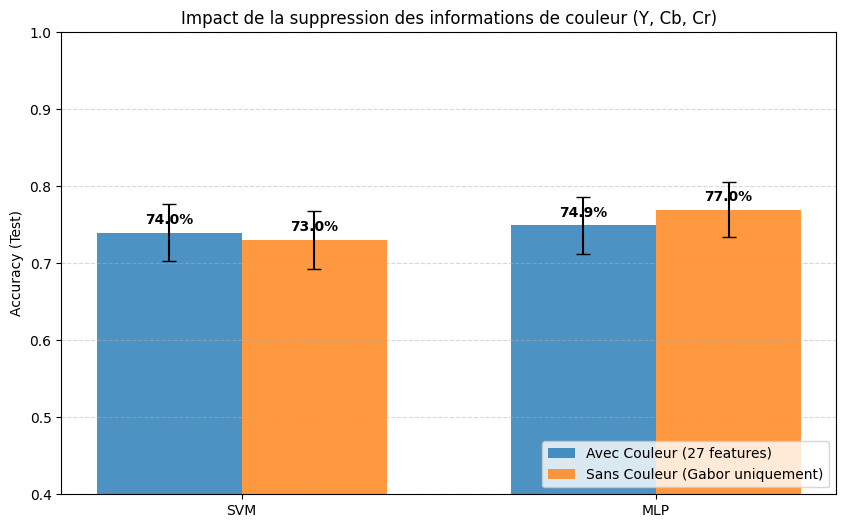

In [120]:
#On teste nos modèles de ML sans les couleurs.
import matplotlib.pyplot as plt
import numpy as np
import math
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

print("--- DÉBUT DE L'ÉTUDE D'ABLATION (SANS COULEUR) ---")

#Préparation des données "Réduites"
# Les 3 dernières colonnes sont Y, Cb, Cr. On les retire.
# On garde les colonnes de 0 à 23 (les 24 filtres Gabor)
X_train_no_color = X_train_scaled[:, :-3]
X_test_no_color = X_test_scaled[:, :-3]

print(f"Shape Originale : {X_train_scaled.shape}")
print(f"Shape Sans Couleur : {X_train_no_color.shape}")

#Entraînement des modèles sur les données réduites
# IMPORTANT : On réutilise les MEILLEURS hyperparamètres trouvés par GridSearch
# pour que la comparaison soit juste.

# SVM
print("\n1. Ré-entraînement du SVM (Gabor seulement)...")
# On récupère les paramètres du meilleur SVM
params_svm = grid_svm.best_params_
svm_no_color = SVC(**params_svm) 
svm_no_color.fit(X_train_no_color, y_train)

# MLP
print("2. Ré-entraînement du MLP (Gabor seulement)...")
# On récupère les paramètres du meilleur MLP
params_mlp = grid_mlp.best_params_
mlp_no_color = MLPClassifier(**params_mlp)
mlp_no_color.fit(X_train_no_color, y_train)

# 3. Évaluation et Comparaison
def get_metrics(model, X, y):
    pred = model.predict(X)
    acc = accuracy_score(y, pred)
    # Marge d'erreur (IC 95%)
    margin = 1.96 * math.sqrt((acc * (1 - acc)) / len(y))
    return acc, margin

# Scores SANS couleur
acc_svm_nc, err_svm_nc = get_metrics(svm_no_color, X_test_no_color, y_test)
acc_mlp_nc, err_mlp_nc = get_metrics(mlp_no_color, X_test_no_color, y_test)

# Scores AVEC couleur (On reprend les valeurs calculées précédemment)
# Si elles ne sont plus en mémoire, on les recalcule rapidement
acc_svm_full, err_svm_full = get_metrics(grid_svm.best_estimator_, X_test_scaled, y_test)
acc_mlp_full, err_mlp_full = get_metrics(grid_mlp.best_estimator_, X_test_scaled, y_test)

# 4. Visualisation Graphique
labels = ['SVM', 'MLP']
acc_full = [acc_svm_full, acc_mlp_full]
acc_nc = [acc_svm_nc, acc_mlp_nc]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))
rects1 = plt.bar(x - width/2, acc_full, width, label='Avec Couleur (27 features)', color='#1f77b4', alpha=0.8, yerr=[err_svm_full, err_mlp_full], capsize=5)
rects2 = plt.bar(x + width/2, acc_nc, width, label='Sans Couleur (Gabor uniquement)', color='#ff7f0e', alpha=0.8, yerr=[err_svm_nc, err_mlp_nc], capsize=5)

plt.ylabel('Accuracy (Test)')
plt.title('Impact de la suppression des informations de couleur (Y, Cb, Cr)')
plt.xticks(x, labels)
plt.legend(loc='lower right')
plt.ylim(0.4, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Fonction pour ajouter les labels
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width()/2., 1.01*height,
                f'{height:.1%}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.show()



DeepLearning


In [121]:
# Cellule 6 : Chargement des Images (Version Corrigée et Validée)
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import utils_ClassIm as utils

# Paramètres
IMG_SIZE = 128 
NB_IMAGES = 2688 # Nombre exact d'images dans la base

print("Chargement des images... cela peut prendre du temps.")

#Chargement via la fonction fournie
raw_images, labels_main, labels_sub = utils.lire_images("./images_128/images_128", './database.csv', NB_IMAGES, sous_ech=2)

# On coupe les tableaux pour ne garder que les 2688 premières valeurs
labels_main = labels_main[:NB_IMAGES]
labels_sub = labels_sub[:NB_IMAGES]

#Conversion et Normalisation des images
X_img = np.array(raw_images)
X_img = (X_img / 255.0) - 0.5 # Centrage des pixels entre -0.5 et 0.5

#Préparation des labels
y_img = np.array(labels_sub)

#Vérification visuelle des tailles (doit afficher 2688 pour les deux)
print(f"Taille X (Images): {len(X_img)}")
print(f"Taille y (Labels): {len(y_img)}")

#Split Train/Test
# On divise en train et test AVANT le one-hot encoding pour garder la cohérence
X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(X_img, y_img, test_size=0.2, random_state=42)

# One-hot encoding pour Keras
y_train_cat = to_categorical(y_train_img - 2, num_classes=8) 
y_test_cat = to_categorical(y_test_img - 2, num_classes=8)

print("-" * 30)
print(f"Données chargées avec succès !")
print(f"Shape Train X: {X_train_img.shape}")
print(f"Shape Train Y: {y_train_cat.shape}")

Chargement des images... cela peut prendre du temps.
Lecture base
Fin Lecture base
Taille X (Images): 2688
Taille y (Labels): 2688
------------------------------
Données chargées avec succès !
Shape Train X: (2150, 64, 64, 3)
Shape Train Y: (2150, 8)


In [ ]:
# Cellule 7 : Modèle CNN "LeNet-like"
def build_lenet(input_shape, num_classes):
    model = Sequential()
    
    # C1: Convolution
    model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', padding='same', input_shape=input_shape))
    # S2: Subsampling (Pooling)
    model.add(MaxPooling2D(pool_size=(2,2)))
    
    # C3: Convolution
    model.add(Conv2D(filters=64, kernel_size=(5,5), activation='relu', padding='same'))
    # S4: Subsampling
    model.add(MaxPooling2D(pool_size=(2,2)))
    
    # Aplatissement
    model.add(Flatten())
    
    # C5/F6: Fully Connected (MLP)
    model.add(Dense(500, activation='relu')) # Couche cachée
    model.add(Dropout(0.5))
    
    # Output
    model.add(Dense(num_classes, activation='softmax'))
    
    # Compilation
    opt = Adam(learning_rate=0.001)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

input_shape = X_train_img.shape[1:] # (Height, Width, Channels)
model_lenet = build_lenet(input_shape, num_classes=8)
model_lenet.summary()

In [ ]:
# Cellule 8 : Apprentissage LeNet
EPOCHS = 20
BATCH_SIZE = 32

history_lenet = model_lenet.fit(
    X_train_img, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2, # Utilise 20% du train pour valider à chaque epoch
    verbose=1
)

# Plot Loss & Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lenet.history['loss'], label='Train Loss')
plt.plot(history_lenet.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lenet.history['accuracy'], label='Train Acc')
plt.plot(history_lenet.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()

On peut voir que à 6 epochs, la loss function de val commence à remonter

In [ ]:
#On teste notre CNN sur la base de test
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import math

print("--- ÉVALUATION DU CNN (Architecture Personnalisée) SUR LE TEST ---")

# 1. Prédictions sur la base de Test
y_pred_probs = model_lenet.predict(X_test_img)

# On prend l'indice de la probabilité la plus haute (ex: classe 1)
y_pred_cnn = np.argmax(y_pred_probs, axis=1)

# On convertit aussi les vrais labels (one-hot) en indices
y_true_cnn = np.argmax(y_test_cat, axis=1)

# 2. Calcul du Score et de l'Intervalle de Confiance
acc_lenet = accuracy_score(y_true_cnn, y_pred_cnn)
n_test = len(y_true_cnn)
margin_lenet = 1.96 * math.sqrt((acc_lenet * (1 - acc_lenet)) / n_test)

print(f"\nAccuracy Globale : {acc_lenet:.2%}")
print(f"Intervalle de Confiance (95%) : [{acc_lenet - margin_lenet:.2%}, {acc_lenet + margin_lenet:.2%}]")

# 3. Rapport de Classification par classe
try:
    target_names = le.classes_
except NameError:
    target_names = ['Cote', 'Foret', 'Autoroute', 'Ville', 'Montagne', 'Open_Country', 'Rue', 'GrandBatiment']

print("\n--- Rapport Détaillé par Classe ---")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=target_names))

# 4. Visualisation de la Matrice de Confusion
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_cnn, y_pred_cnn)

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=target_names, yticklabels=target_names)

plt.title(f'Matrice de Confusion : CNN "LeNet" (Accuracy: {acc_lenet:.2%}+/- ({margin_lenet:.2%}))', fontsize=14)
plt.xlabel('Classe Prédite')
plt.ylabel('Vraie Classe')
plt.show()



Transfert Learning

In [ ]:
# Cellule 9 : Transfer Learning VGG16 (Feature Extraction)

# 1. Charger VGG16 sans la partie classifier (include_top=False)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

# 2. Geler les couches de convolution (Ne pas entraîner)
for layer in base_model.layers:
    layer.trainable = False 

# 3. Ajouter notre propre classifieur
x = base_model.output
x = Flatten()(x)
x = Dense(500, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(8, activation='softmax')(x) # 8 classes

# 4. Créer le modèle final
model_transfer = Model(inputs=base_model.input, outputs=predictions)

# 5. Compiler
model_transfer.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

model_transfer.summary()

In [ ]:
# Cellule 10 : Entraînement Transfer Learning
history_transfer = model_transfer.fit(
    X_train_img, y_train_cat,
    epochs=10, # Peut nécessiter moins d'epochs car pré-entraîné
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Évaluation rapide
score = model_transfer.evaluate(X_test_img, y_test_cat, verbose=0)
print(f"Test Accuracy (Transfer Learning): {score[1]:.2f}")

FineTuning

In [ ]:
# Cellule 11 : Fine-Tuning
from tensorflow.keras.models import clone_model

# --- 1. VRAIE COPIE DU MODÈLE ---
print("Clonage du modèle pour préserver l'original...")
# Copie de l'architecture
model_finetuned = clone_model(model_transfer)
# Copie des poids 
model_finetuned.set_weights(model_transfer.get_weights())
Nbr_couches_gelees = 15 

for layer in model_finetuned.layers[:Nbr_couches_gelees]:
    layer.trainable = False
for layer in model_finetuned.layers[Nbr_couches_gelees:]:
    layer.trainable = True

# Recompiler avec un learning rate très faible pour ne pas casser les poids pré-appris
opt_fine = SGD(learning_rate=0.0001, momentum=0.9)
model_finetuned.compile(optimizer=opt_fine, loss='categorical_crossentropy', metrics=['accuracy'])

print("Début du Fine-Tuning...")
history_finetune = model_finetuned.fit(
    X_train_img, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Évaluation Finale
final_score = model_finetuned.evaluate(X_test_img, y_test_cat, verbose=0)
print(f"Accuracy Finale après Fine-Tuning: {final_score[1]:.2f}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from sklearn.metrics import confusion_matrix, accuracy_score

# --- 1. Prédictions et Calculs pour les 4 Modèles ---
# Variables pour stocker les résultats
accuracies = []
margins = []
models_names = ['1. SVM (Gabor)', '2. LeNet (Scratch)', '3. VGG16 (Gelé)', '4. VGG16 (Fine-Tuned)']

# A. Modèle Classique (SVM)
print("1. Calcul des prédictions SVM...")
y_pred_svm = best_svm_model.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
n_test = len(y_test)
margin_svm = 1.96 * math.sqrt((acc_svm * (1 - acc_svm)) / n_test)
conf_int_svm = (acc_svm - margin_svm, acc_svm + margin_svm)
conf_mx_svm = confusion_matrix(y_test, y_pred_svm)

accuracies.append(acc_svm)
margins.append(margin_svm)

# Note : y_true est le même pour tous les CNN
y_true_cnn = np.argmax(y_test_cat, axis=1)

# B. Modèle CNN "From Scratch" (LeNet)
print("2. Calcul des prédictions LeNet...")
y_pred_proba_lenet = model_lenet.predict(X_test_img)
y_pred_lenet = np.argmax(y_pred_proba_lenet, axis=1)
acc_lenet = accuracy_score(y_true_cnn, y_pred_lenet)
margin_lenet = 1.96 * math.sqrt((acc_lenet * (1 - acc_lenet)) / n_test)
conf_int_lenet = (acc_lenet - margin_lenet, acc_lenet + margin_lenet)
conf_mx_lenet = confusion_matrix(y_true_cnn, y_pred_lenet)

accuracies.append(acc_lenet)
margins.append(margin_lenet)

# C. Modèle Transfer Learning (Gelé)
print("3. Calcul des prédictions VGG16 (Transfert simple)...")
y_pred_proba_trans = model_transfer.predict(X_test_img)
y_pred_trans = np.argmax(y_pred_proba_trans, axis=1)
acc_trans = accuracy_score(y_true_cnn, y_pred_trans)
margin_trans = 1.96 * math.sqrt((acc_trans * (1 - acc_trans)) / n_test)
conf_int_trans = (acc_trans - margin_trans, acc_trans + margin_trans)
conf_mx_trans = confusion_matrix(y_true_cnn, y_pred_trans)

accuracies.append(acc_trans)
margins.append(margin_trans)

# D. Modèle Fine-Tuning (Dégelé)
print("4. Calcul des prédictions VGG16 (Fine-Tuning)...")
try:
    y_pred_proba_ft = model_finetuned.predict(X_test_img) 
    y_pred_ft = np.argmax(y_pred_proba_ft, axis=1)
    acc_ft = accuracy_score(y_true_cnn, y_pred_ft)
    margin_ft = 1.96 * math.sqrt((acc_ft * (1 - acc_ft)) / n_test)
    conf_int_ft = (acc_ft - margin_ft, acc_ft + margin_ft)
    conf_mx_ft = confusion_matrix(y_true_cnn, y_pred_ft)
    
    accuracies.append(acc_ft)
    margins.append(margin_ft)
    has_finetuning = True
except NameError:
    print("ATTENTION : Le modèle 'model_finetuned' n'est pas défini. La 4ème colonne sera vide.")
    has_finetuning = False

# --- 2. Visualisation Quadruple ---

try:
    labels_names = le.classes_
except NameError:
    labels_names = ['Cote', 'Foret', 'Autoroute', 'Ville', 'Montagne', 'Open_Country', 'Rue', 'GrandBatiment']

# On crée 4 sous-graphiques
fig, axes = plt.subplots(1, 4, figsize=(28, 6), sharey=True)

# 1. SVM
sns.heatmap(conf_mx_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=labels_names, yticklabels=labels_names)
axes[0].set_title(f'{models_names[0]}\nAcc: {acc_svm:.1%} ± {margin_svm:.1%}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Vraie Classe')
axes[0].set_xlabel('Classe Prédite')

# 2. LeNet
sns.heatmap(conf_mx_lenet, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False,
            xticklabels=labels_names, yticklabels=labels_names)
axes[1].set_title(f'{models_names[1]}\nAcc: {acc_lenet:.1%} ± {margin_lenet:.1%}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Classe Prédite')

# 3. Transfer (Gelé)
sns.heatmap(conf_mx_trans, annot=True, fmt='d', cmap='Greens', ax=axes[2], cbar=False,
            xticklabels=labels_names, yticklabels=labels_names)
axes[2].set_title(f'{models_names[2]}\nAcc: {acc_trans:.1%} ± {margin_trans:.1%}', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Classe Prédite')

# 4. Fine-Tuning
if has_finetuning:
    sns.heatmap(conf_mx_ft, annot=True, fmt='d', cmap='Reds', ax=axes[3], cbar=False,
                xticklabels=labels_names, yticklabels=labels_names)
    axes[3].set_title(f'{models_names[3]}\nAcc: {acc_ft:.1%} ± {margin_ft:.1%}', fontsize=12, fontweight='bold')
    axes[3].set_xlabel('Classe Prédite')
else:
    axes[3].axis('off')
    axes[3].set_title("Modèle Fine-Tuning non trouvé")

plt.tight_layout()
plt.show()

# --- 3. Conclusion Statistique Complète ---
print("-" * 100)
print(f"{'Modèle':<25} | {'Accuracy':<10} | {'Intervalle de Confiance (95%)':<30}")
print("-" * 100)
print(f"{models_names[0]:<25} | {acc_svm:.2%}     | [{conf_int_svm[0]:.2%}, {conf_int_svm[1]:.2%}]")
print(f"{models_names[1]:<25} | {acc_lenet:.2%}     | [{conf_int_lenet[0]:.2%}, {conf_int_lenet[1]:.2%}]")
print(f"{models_names[2]:<25} | {acc_trans:.2%}     | [{conf_int_trans[0]:.2%}, {conf_int_trans[1]:.2%}]")
if has_finetuning:
    print(f"{models_names[3]:<25} | {acc_ft:.2%}     | [{conf_int_ft[0]:.2%}, {conf_int_ft[1]:.2%}]")
print("-" * 100)

# Comparaisons clés
def compare_intervals(name1, int1, name2, int2):
    overlap = max(int1[0], int2[0]) <= min(int1[1], int2[1])
    diff = (int2[0] + int2[1])/2 - (int1[0] + int1[1])/2
    print(f"Duel {name1} vs {name2} : ", end="")
    if overlap:
        print(f"ÉGALITÉ STATISTIQUE (Chevauchement). Diff: {diff*100:+.1f}%")
    else:
        winner = name2 if diff > 0 else name1
        print(f"VICTOIRE SIGNIFICATIVE de {winner}.")

print("\n--- ANALYSE DES DUELS ---")
if has_finetuning:
    compare_intervals("VGG Gelé", conf_int_trans, "VGG Fine-Tuned", conf_int_ft)
    compare_intervals("SVM", conf_int_svm, "VGG Fine-Tuned", conf_int_ft)